# MK 1MS041 Data Science — Day10 Exam 2026-01-16 Compilation

This notebook compiles all uploaded notebooks in the requested order.

## Clickable index / contents

- [exam20260116](#exam20260116)  SVD, classification, confidence intervals, Markov chain
- [Day9 mock exam](#day9-mock-exam) - simulation, confidence intervals, classification, Markov chains, SVD, optimization
- [Day1](#day1) - Conditional probability, Independence and complements, Binomial/geometric simulations, Distribution of a transformed random variable, Monte Carlo approximation, Hoeffding confidence intervals, NumPy vectorization and plotting
- [Day2](#day2) - CDF/PDF reasoning, inverse transform sampling, rejection sampling, simulation validation, empirical probability estimation
- [Day3](#day3)  Statistical estimation and confidence intervals, estimator distribution, bias, variance, standard error, MSE, simulation studies, Hoeffding confidence intervals
- [Day4](#day4)  Linear regression and data pipeline, synthetic data generation, feature engineering, train/test split, linear regression with NumPy / scikit-learn, MAE, MSE, RMSE, $R^2$, simple data pipeline thinking
- [Day5](#day5)  Logistic regression and classification, - binary classification, logistic regression, train/test split, probabilities and thresholds, confusion matrix, precision, recall, F1, expected cos
- [Day6](#day6)  Markov chain, transition matrix, simulation of Markov chains, state probabilities, stationary distribution, hitting time, long-run behavior
- [Day7](#day7)  Matrix algebra, SVD, High-Dimentional geometry, vectors and norms, dot products and cosine similarity, high-dimensional geometry, matrix rank, SVD, low-rank approximation
- [Day8](#day8)   Optimization and count regression, Poisson regression, negative log-likelihood, gradient descent, learning rate, convergence, count data
- [Day10](#day10)



---

<a id="exam20260116"></a>

# exam20260116

**Source file:** `ExamDataScience20260116_MK_after(2).ipynb`



# Exam 16th of January 2026, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [8]:
# Insert your anonymous exam ID as a string in the variable below
examID="0013-UNF"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


This problem is about **SVD** and a simple **anomaly detection** idea using low-rank reconstruction.



Unless stated otherwise, when you are asked to produce a matrix or vector, it must be a **NumPy array**.

1. **[4p] SVD.** Load `data/SVD.csv` as instructed in the code cell. Let $X$ be the data matrix of shape `n_samples × n_dimensions`. Compute an SVD
   $$X = U D V^T$$
   where $U$ has shape `n_samples × n_dimensions`, $D$ is the diagonal matrix of shape `(n_dimensions,n_dimensions)` that has the singular values on the diagonal (see documentation for `np.diag`), and $V$ has shape `n_dimensions × n_dimensions`.
   **Important:** `np.linalg.svd` returns `U, d, Vt` where `Vt` is $V^T$.
   Also extract the **first** right and left singular vectors and store them as 1D arrays in the variables provided.

2. **[3p] Explained variance.** For $N =$ `n_dimensions`, define the explained variance using the first $k$ singular values as
   $$
   \mathrm{EV}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^N \sigma_i^2}.
   $$
   Compute $\mathrm{EV}(k)$ for $k=1,2,\dots,N$ and store it in `problem1_explained_variance` (length `N`). Then set `problem1_num_components` to the **smallest** $k$ such that $\mathrm{EV}(k) \ge 0.99$.

3. **[3p] Plot + interpretation.** Plot explained variance (x-axis: number of components $k$, y-axis: $\mathrm{EV}(k)$). In the markdown cell below, reason about the shape of the curve for this dataset.

4. **[4p] Low-rank reconstruction + outliers.**
   - Using `problem1_num_components`, construct the best rank-$k$ approximation of $X$ and store it in `problem1_approximation`.
   - Compute the row-wise Euclidean reconstruction error $\|X_i - \hat X_i\|_2$ for each row $i$ and store it in `problem1_reconstruction_error` (shape `(n_samples,)`).
   - Plot the empirical distribution function (EDF) of the reconstruction errors (you may use `makeEDF` / `plotEDF` from `Utils.py`).
   - Choose a threshold `problem1_threshold` so that **exactly 100** samples are flagged as outliers (i.e. have reconstruction error >= the threshold).
   - Store those flagged rows in `problem1_outliers` (shape `(100, n_dimensions)`).


In [9]:
# Part 1: 4 points

# Load the data from the file data/SVD.csv and store the data in a numpy array called problem1_data below
# Double check that the numbers have been parsed correctly by checking the dtype of the array by calling problem1_data.dtype
#problem1_data = XXX # A numpy array of shape n_samples x n_dimensions

#problem1_U = XXX # The matrix of left singular vectors of problem1_data with shape n_samples x n_dimensions
#problem1_D = XXX # The diagonal matrix with the singular values of problem1_data on the diagonal with shape n_dimensions x n_dimensions
#problem1_V = XXX # The matrix of right singular vectors of problem1_data with shape n_dimensions x n_dimensions

#problem1_first_right_singular_vector = XXX # The first right singular vector of problem1_data with shape (n_dimensions,) hint sometimes one needs to invoke flatten() to avoid having shape (n_dimensions, 1) or (1, n_dimensions)

#problem1_first_left_singular_vector = XXX # The first left singular vector of problem1_data with shape (n_samples,) hint sometimes one needs to invoke flatten() to avoid having shape (n_samples, 1) or (1, n_samples)
import numpy as np
import matplotlib.pyplot as plt
#from np.linalg import svd

# Load data
# Replace with actual path
problem1_data = np.loadtxt('data/SVD.csv', delimiter=',')
#print(X)

# TODO: Compute SVD
#U, d, Vt = None, None, None
U, d, Vt = np.linalg.svd(problem1_data)
#print("U=", U)
#print("d=", d)
#print("Vt=", Vt)
problem1_U = U
problem1_D = np.diag(d)
problem1_V = Vt.T

# TODO: Extract first singular vectors
problem1_first_right_singular_vector = problem1_V[:,0]
problem1_first_left_singular_vector = problem1_U[:,0]
print("V=", problem1_first_right_singular_vector)
print("D=", problem1_first_left_singular_vector)

#print(X.shape)
#print(U.shape)
#print(D.shape)
#print(V.shape)
#print(first_right.shape)
#print(first_left.shape)

V= [-0.05825103  0.0018973   0.11086397  0.05218048  0.02807002 -0.04026384
  0.18251657  0.0326072   0.00534245 -0.07637272 -0.00649968 -0.09280313
  0.29322778  0.13374641 -0.04464938  0.14584424 -0.00318634  0.0273236
 -0.00996777  0.05553341  0.11845217  0.20188375  0.13444786  0.20215225
 -0.13261902 -0.01886261 -0.1261721   0.13486816  0.11198838  0.14000152
 -0.00298937 -0.21856926  0.05495356 -0.08299475  0.0242812   0.08840831
  0.0414773   0.0769017   0.07575324 -0.03576804 -0.02435765 -0.22113252
  0.00442148 -0.07549467  0.0068233  -0.09671464  0.00758961 -0.03956649
  0.13791302  0.17554336 -0.12270213  0.02976898  0.16946915  0.05404305
 -0.02381588  0.09693949  0.00653543 -0.03348893  0.03761882 -0.10280221
 -0.12907854  0.04990095  0.10184541  0.14604316 -0.07125689 -0.09391735
  0.17374352 -0.07326511  0.01287067 -0.06276502 -0.06425487  0.01066338
 -0.00346424  0.11917023  0.00156164  0.11552805 -0.0209829   0.04761493
 -0.00193893 -0.22216271  0.10982856  0.0422615  

In [10]:
# Part 2: 3 points

# Calculate the explained variance of using 1,2,3,...,n_dimensions singular values and store it as a numpy array called problem1_explained_variance below
#problem1_explained_variance = XXX # A numpy array of shape (n_dimensions,), it should be an increasing sequence of positive numbers and the last element should be 1

# Store in the variable below the smallest number of singular values needed to explain at least 99% of the variance
#problem1_num_components = XXX # An integer

# squared singular values
d_squared = d**2

# cumulative explained variance
problem1_explained_variance = np.cumsum(d_squared) / np.sum(d_squared)

# smallest k such that EV(k) >= 0.99
problem1_num_components = np.argmax(problem1_explained_variance >= 0.99) + 1
print(problem1_explained_variance)
print(problem1_num_components)
print(problem1_explained_variance.size)

[0.16233339 0.31142268 0.42750646 0.5345299  0.63093263 0.72663179
 0.80394305 0.87633669 0.94444296 0.99907483 0.99923126 0.99935627
 0.99947819 0.99958185 0.99966931 0.99975142 0.99982953 0.99989362
 0.99994861 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.       

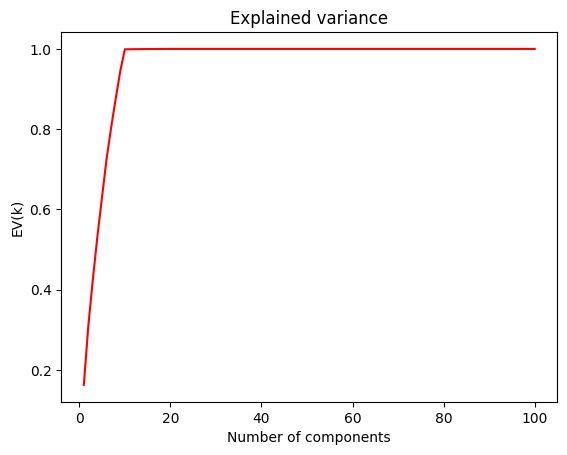

In [11]:
# Part 3: 3 points

# Put the code below to plot the explained variance
# use for instance matplotlib
# XXX
# XXX
# XXX

# Plot explained variance
import numpy as np 
import matplotlib.pyplot as plt 

y = problem1_explained_variance
#x = np.arange(1,explained_variance.size+1) 
x = np.arange(1,len(y)+1) 

# plotting
plt.title("Explained variance") 
plt.xlabel("Number of components") 
plt.ylabel("EV(k)") 
plt.plot(x, y, color ="red") 
plt.show()





## Free-text answer (Part 3)



In 2–5 sentences:



- Describe the *shape* of the explained-variance curve.

- Explain why it looks like that for this dataset.



Write your explanation below this line.
Explanation of the plot: The curve rises sharply, then quickly flattens.
Most variance is captured by few components.
The dataset has low effective dimensionality.

In [12]:
# Part 4: 4 points

# Calculate the approximating matrix of problem1_data using the first problem1_num_components singular values and store it in the variable below
#problem1_approximation = XXX # A numpy array of shape n_samples x n_dimensions

# Calculate the reconstruction error of problem1_data using problem1_approximation and store it in the variable below (should have shape (n_samples,)) (row wise Euclidean distance)
#problem1_reconstruction_error = XXX

# Put the code below to plot the empirical distribution function of the reconstruction error
# You can use the Utils.py file for plotting the empirical distribution function, makeEDF and plotEDF functions
# XXX
# XXX
# XXX


# Store the value of the selected threshold in the variable below
#problem1_threshold = XXX

# Finally store the samples of problem1_data that have a reconstruction error larger than problem1_threshold in the variable below, should have shape (100, n_dimensions)
#problem1_outliers = XXX



# Reconstruction and errors
# TODO
k=problem1_num_components
U_k=problem1_U[:,:k]     #first column
Vt_k=problem1_V[:k,:]   #first row
d_k=d[:k]
D_k=np.diag(d_k)
#D is diagonal matrix
print(U_k.shape)
print(D_k.shape)
print(Vt_k.shape)
problem1_approximation = U_k@D_k@Vt_k
print(problem1_approximation)
#errors = None
#errors = np.sqrt(np.sum((X - X_k)**2, axis=1))
problem1_reconstruction_error = np.linalg.norm(problem1_data - problem1_approximation, axis=1)
print("errors=", problem1_reconstruction_error)

# TODO: choose threshold for 100 outliers
errors_asc_order = np.sort(problem1_reconstruction_error)
print(errors_asc_order)
problem1_threshold = errors_asc_order[-100]
print("treshold=", problem1_threshold)
problem1_outliers = problem1_data[problem1_reconstruction_error >=problem1_threshold]
problem1_outliers= problem1_outliers[:100]
print("outliers=", problem1_outliers)

(1010, 10)
(10, 10)
(10, 100)
[[-6.08139632 -0.4001299  -3.44091876 ...  8.82968941 -5.44120394
  -4.69354615]
 [-2.93417063  1.56290269 -2.09798942 ... -0.16056841 -5.15162323
  -1.64940435]
 [ 0.75464863 -1.14570515  2.36019377 ...  0.05784701  2.64616258
   1.15643425]
 ...
 [ 3.66757205  3.16935384  5.00003817 ...  2.54850498 -5.24687259
   1.48475179]
 [-0.88223783 -1.03903008 -4.2832899  ...  1.23002765 -2.40416432
  -4.53180573]
 [ 2.00799504  1.55315815  2.17750285 ... -0.80238039  0.30210107
   4.69320276]]
errors= [55.86478997 50.98241158 23.54770658 ... 57.16213477 31.02894362
 47.58436775]
[ 9.51598636  9.80302141 10.0625799  ... 72.98112864 74.75971663
 83.75914044]
treshold= 56.39649034649454
outliers= [[ 2.51486136  0.86677404 -1.35794135 ... -0.36335466 -0.35189751
  -2.90519338]
 [ 4.86941073 -0.41227276 -2.13524289 ... -0.20392699 -1.38557316
   0.90429882]
 [-6.73363711  0.16177579 -1.46552299 ...  2.39508712 -3.90141579
  -0.9717655 ]
 ...
 [10.12216054  1.19823835 

---
## Exam vB, PROBLEM 2
Maximum Points = 12


In this problem we are interested in **account takeover (ATO) detection** for an online service. You are given the outputs of a classifier that predicts the probability that a login attempt is malicious ($Y=1$). Your goal is to explore how the **decision threshold** affects business cost (as in the thresholding assignment).

A threshold $t \in [0,1]$ is used to convert predicted probabilities $\hat p(x)=P(Y=1\mid x)$ to labels: predict $\hat y=1$ if $\hat p(x)\ge t$, else $\hat y=0$.

The costs associated with the decisions are:

* **True Positive (TP)**: correctly flagging an ATO login costs **80** (extra verification + friction).
* **True Negative (TN)**: allowing a legitimate login has **0** cost.
* **False Positive (FP)**: incorrectly flagging a legitimate login costs **150** (support load + churn risk).
* **False Negative (FN)**: missing an ATO login costs **900** (fraud + remediation).

**The code cells contain more detailed instructions; THE FIRST CODE CELL INITIALIZES YOUR VARIABLES.**

1. **[3p]** Complete the function `problem2_avg_cost` to compute the **average cost per sample** of a model under a certain prediction threshold. Plot the cost as a function of the threshold (using the validation data provided in the first code cell of this problem), from 0 to 1 with step size 0.01.
2. **[2.5p]** Find the threshold that minimizes the cost and calculate the cost at that threshold on the validation data. Also calculate the precision and recall at the optimal threshold, treating **class 1 as the positive class** and **class 0 as the positive class** separately.
3. **[2.5p]** Repeat step 2, but this time find the best threshold to **maximize accuracy** (equivalently, minimize the $0{-}1$ loss). Calculate the difference in cost between the threshold found in part 3 and the one found in part 2.
4. **[4p]** Provide a confidence interval around the optimal cost (with $95\%$ confidence) applied to the test data using **Hoeffding's inequality**, and explain all assumptions you made.

In [13]:

# RUN THIS CELL TO GET THE DATA

# We start by loading the data 

import pandas as pd

PROBLEM2_DF = pd.read_csv('data/fraud.csv')
Y = PROBLEM2_DF['Class'].values
X = PROBLEM2_DF[['V%d' % i for i in range(1,5)]+['Amount']].values

# We will split the data into training, testing and validation sets
from Utils import train_test_validation
PROBLEM2_X_train, PROBLEM2_X_test, PROBLEM2_X_val, PROBLEM2_y_train, PROBLEM2_y_test, PROBLEM2_y_val = train_test_validation(X,Y,shuffle=True,random_state=1)

# From this we will train a logistic regression model with scaling and simple hyperparameter search
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=1))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
gs.fit(PROBLEM2_X_train, PROBLEM2_y_train)

# use the best pipeline (it supports predict_proba)
lr = gs.best_estimator_

# THE FOLLOWING CODE WILL PRODUCE THE ARRAYS YOU NEED FOR THE PROBLEM
PROBLEM2_y_pred_proba_val = lr.predict_proba(PROBLEM2_X_val)[:,1]
PROBLEM2_y_true_val = PROBLEM2_y_val

PROBLEM2_y_pred_proba_test = lr.predict_proba(PROBLEM2_X_test)[:,1]
PROBLEM2_y_true_test = PROBLEM2_y_test

print(PROBLEM2_DF.head())
print('PROBLEM2_y_pred_proba_val:',  PROBLEM2_y_pred_proba_val)
print('PROBLEM2_y_true_val:', PROBLEM2_y_true_val)
print('PROBLEM2_y_pred_proba_test:',  PROBLEM2_y_pred_proba_test)
print('PROBLEM2_y_true_test:', PROBLEM2_y_true_test)

       Time        V1        V2        V3        V4        V5        V6  \
0  125612.0  1.889618  1.073099 -1.678018  4.173268  1.015516 -0.009389   
1  132086.0 -0.361428  1.133472 -2.971360 -0.283073  0.371452 -0.574680   
2   94952.0  0.842025 -0.365518 -2.464063  4.820886  0.775505 -0.614785   
3  160791.0  2.132386  0.705608 -3.530759  0.514779  1.527175 -1.716268   
4   35926.0 -3.896583  4.518355 -4.454027  5.547453 -4.121459 -1.163407   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0 -0.079706  0.064071 -0.714517  ...  0.203728  0.733796 -0.036560  0.334306   
1  4.031513 -0.934398 -0.768255  ...  0.110815  0.563861 -0.408436 -0.880079   
2  1.368024 -0.526262 -0.121356  ... -0.110622 -1.257800 -0.324418 -0.420020   
3  1.132791 -0.574214  0.128904  ...  0.163739  0.703910 -0.245076  0.460049   
4 -6.805053  2.928356 -4.917130  ...  1.691042  0.920021 -0.151104  0.011007   

        V25       V26       V27       V28  Amount  Class  
0  0.1471

In [14]:

# Part 1: 3 points
# Implement the following function that calculates the average cost per sample of a binary classifier
# according to the specification in the problem statement.
# See the comments inside the function for details of the parameters.
def problem2_avg_cost(y_true, y_predict_proba, threshold):
    # y_true is a numpy array of shape (n_samples,) with binary labels (1 = ATO, 0 = legitimate)
    # y_predict_proba is a numpy array of shape (n_samples,) with predicted probabilities for class 1
    # threshold is a float between 0 and 1
    
    # Return the average cost per sample (a single float value).
    # Hint: Convert probabilities to predictions using >= threshold,
    # then compute the cost based on the confusion matrix entries (TP, TN, FP, FN).

    ##return XXX  # A float
    total_cost= 0
    total_cost_sum = 0
    for j in range(len(y_predict_proba)):
        # Probability of class 1 (positive)
        p_pos = y_predict_proba[j]
        #print(p_pos)
        #Decision rule: predict 1 if P(Y=1) >= threshold else 0
        y_pred = (p_pos >= threshold).astype(int) 
        Y = y_true[j]   
        fn = (Y == 1) & (y_pred == 0)   # positive classified as negative  fn=900
        fp = (Y == 0) & (y_pred == 1)   # negative classified as positive  fp=150
        tp = (Y == 1) & (y_pred == 1)   # positive classified as positive  tp=80
        tn = (Y == 0) & (y_pred == 0)   # negavite classified as negative  tn=0
        total_cost = fn.sum() * 900 + fp.sum() * 150 + tp.sum() * 80 + tn.sum() * 0
        total_cost_sum =  total_cost_sum +total_cost
        #print(total_cost_sum, total_cost)

    # Average cost (as requested)
    return total_cost_sum/len(y_predict_proba)

# Verify outputs
example_threshold = 0.81
example_cost = problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, example_threshold)
print(f"Cost at threshold {example_threshold}: {example_cost}")


# Provide the code below to plot the cost as a function of the threshold
# using the validation data, specifically the arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# The plot should range from threshold 0 to 1 with step size 0.01.
# The y-axis should be the average cost and the x-axis should be the threshold.

# Write the code below to produce the scatter plot for part 5


Cost at threshold 0.81: 66.7699530516432


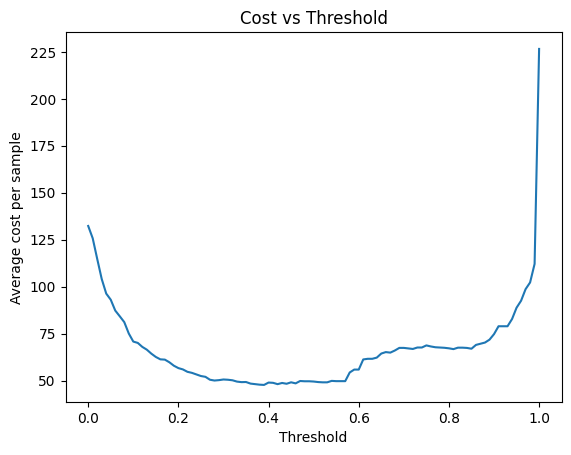

In [15]:
#plot 
# Provide the code below to plot the cost as a function of the threshold
# using the validation data, specifically the arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# The plot should range from threshold 0 to 1 with step size 0.01.
# The y-axis should be the average cost and the x-axis should be the threshold.
import matplotlib.pyplot as plt
import numpy as np

np.arange(0, 1.01, 0.01)
#this creates [0.00, 0.01, 0.02, ..., 1.00]
thresholds = np.arange(0, 1.01, 0.01)

costs = []   #create empty cost list
#compute cost for that threashhold
for t in thresholds:
    costs.append(problem2_avg_cost(
        PROBLEM2_y_true_val,
        PROBLEM2_y_pred_proba_val,
        t
    ))

#Why Use Validation Data? Because:
#validation set is used for threshold selection
#test set must remain untouched for final evaluation
#This is standard ML methodology.

#plot
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Average cost per sample")
plt.title("Cost vs Threshold")
plt.show()

In [16]:
# Part 2: 2.5 points
# Use the cost function you implemented above to find the threshold that minimizes the average cost
# on the validation data (PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val).
# Store the optimal threshold in the variable below.
#problem2_threshold = XXX  # A float between 0 and 1

# Calculate the average cost at the optimal threshold on the validation data.
# Store the cost in the variable below.
#problem2_cost_val = XXX  # A float




# Candidate thresholds
thresholds = np.linspace(0.0, 1.0, 101)
#print(thresholds)

validation_costs = []

for t in thresholds:
    cost= problem2_avg_cost(PROBLEM2_y_true_test, PROBLEM2_y_pred_proba_test, t)
    validation_costs.append(cost)

# Convert to numpy array
validation_costs = np.array(validation_costs)
#print(costs)

# Index of minimum cost
best_idx = np.argmin(validation_costs)

# Optimal threshold
problem2_threshold = thresholds[best_idx]
#average cost at the optimal threshold on the validation data.
problem2_cost_val = validation_costs[best_idx]

# Verify outputs
print(f"Optimal threshold: {problem2_threshold}")
print(f"Cost at optimal threshold: {problem2_cost_val}")

Optimal threshold: 0.27
Cost at optimal threshold: 43.71830985915493


In [17]:
# Part 2: 2.5 points
# Using the optimal threshold, compute the predicted labels on the validation data.
# Store the predicted labels in the variable below.
#problem2_y_pred_val = decision_from_proba(PROBLEM2_y_pred_proba_val, problem2_threshold)  # A numpy array of shape (n_samples,) with values 0 or 1
# Calculate precision and recall treating class 1 as the positive class.
#problem2_precision_1 = XXX  # A float between 0 and 1
#problem2_recall_1 = XXX  # A float between 0 and 1

# Calculate precision and recall treating class 0 as the positive class.
#problem2_precision_0 = XXX  # A float between 0 and 1
#problem2_recall_0 = XXX  # A float between 0 and 1
# calculate precision, and recall on both classes
from sklearn.metrics import precision_score, recall_score

# Convert probabilities to binary predictions
problem2_y_pred_val = (PROBLEM2_y_pred_proba_val >= problem2_threshold).astype(int)

problem2_precision_1 = precision_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=1)
problem2_recall_1 = recall_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=1)

roblem2_precision_0 = precision_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=0)
problem2_recall_0 = recall_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=0)

# Verify outputs
print(f"Predictions problem2_y_pred_val: {problem2_y_pred_val}")
print(f"Precision class 1: {problem2_precision_1}")
print(f"Recall class 1: {problem2_recall_1}")
print(f"Precision class 0: {roblem2_precision_0}")
print(f"Recall class 0: {problem2_recall_0}")


Predictions problem2_y_pred_val: [1 1 0 ... 1 0 0]
Precision class 1: 0.6925207756232687
Recall class 1: 0.929368029739777
Precision class 0: 0.9730113636363636
Recall class 0: 0.8605527638190955


In [18]:
#Predict class labels

def decision_from_proba(p, threshold=0.5):
    # Predict class labels from probabilities under equal costs.
    return (p >= threshold).astype(int)

decision_from_proba(PROBLEM2_y_pred_proba_val, threshold=0.5)

array([1, 1, 0, ..., 1, 0, 0], shape=(1065,))

In [19]:
# Part 3: 2.5 points

# Find the threshold that **maximizes accuracy** on the validation data
# (equivalently, minimizes the 0-1 loss).
# Use the validation arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# Store the accuracy-optimal threshold in the variable below.
from sklearn.metrics import accuracy_score
thresholds = np.linspace(0,1,101)
accuracies = []

for t in thresholds:
    y_pred = (PROBLEM2_y_pred_proba_val >= t).astype(int)
    acc = accuracy_score(PROBLEM2_y_true_val, y_pred)
    accuracies.append(acc)

#Maximum accuracy
best_idx = np.argmax(accuracies)
problem2_threshold_acc = thresholds[best_idx]
print(problem2_threshold_acc)
#problem2_threshold_acc = XXX  # A float between 0 and 1

# Calculate the difference in average cost between:
#   cost at accuracy-optimal threshold (this part) minus cost at cost-optimal threshold (part 2).
# That is: problem2_avg_cost(..., problem2_threshold_acc) - problem2_avg_cost(..., problem2_threshold)  
problem2_cost_difference = problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, problem2_threshold_acc) - problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, problem2_threshold)
#problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, t)
print(problem2_cost_difference)

0.85
16.50704225352112


In [20]:
#construct function for Hoeffding's inequality
def hoeffding_ci_01(loss_estimate, n, delta=0.05):
    # Hoeffding CI for 0-1 loss (bounded in [0,1]).
    radius = np.sqrt(np.log(2.0 / delta) / (2.0 * n))
    return float(loss_estimate - radius), float(loss_estimate + radius)

In [21]:
# Part 4: 4 points

# Using the cost-optimal threshold from part 2 (problem2_threshold), apply Hoeffding's inequality
# to provide a 95% confidence interval for the **average cost** on the test data.
# Use the test arrays PROBLEM2_y_true_test and PROBLEM2_y_pred_proba_test.
# Store the lower and upper bounds of the confidence interval in the variables below.
# Part 4
import numpy as np

delta = 0.05
n = len(PROBLEM2_y_true_test)

# Empirical average cost on test data
optimal_test_cost = problem2_avg_cost(
    PROBLEM2_y_true_test,
    PROBLEM2_y_pred_proba_test,
    problem2_threshold
)

# Hoeffding bounds
a = 0
b = 900

epsilon = (b - a) * np.sqrt(np.log(2 / delta) / (2 * n))

problem2_lower_bound = optimal_test_cost - epsilon
problem2_upper_bound = optimal_test_cost + epsilon

print("Average test cost:", optimal_test_cost)
print("95% Hoeffding CI:", (problem2_lower_bound, problem2_upper_bound))

#problem2_lower_bound = XXX  # A float
#problem2_upper_bound = XXX  # A float



Average test cost: 43.71830985915493
95% Hoeffding CI: (np.float64(6.264160375602572), np.float64(81.17245934270728))



## Free text answer

Put your explanation for part 4 below this line in this **cell**. Double-click to enter edit mode.

In particular, clearly state:
1. Why Hoeffding's inequality applies (or approximately applies) in this context.
Hoeffding’s inequality applies because the average test cost is computed as the mean of independent bounded random variables. Each test sample produces a random cost depending on whether the prediction is TP, TN, FP, or FN. Assuming the test samples are i.i.d. (independent and identically distributed), Hoeffding’s inequality can be used to bound the deviation between the empirical average cost and the true expected cost.
2. What random variables are assumed i.i.d. and what their support is.
The random variables are the per-sample costs:

Xi∈{0,80,150,900}

where:

0 corresponds to a True Negative,
80 corresponds to a True Positive,
150 corresponds to a False Positive,
900 corresponds to a False Negative.
We assume these per-sample costs are i.i.d. because the test examples are assumed to be independently drawn from the same underlying distribution.
3. What bound you used for the per-sample cost range (i.e., $C_{\max} - C_{\min} = ?$ for this problem).
The support of the random variables is bounded between:

C min=0

and

C max=900

Therefore:

Cmax−Cmin=900

This bounded range is required for applying Hoeffding’s inequality.

---
## Exam vB, PROBLEM 3
Maximum Points = 14


A courier company monitors its trucks across four states:

*   **Downtown (D)**
*   **Suburbs (S)**
*   **Countryside (C)**
*   **Maintenance (M)** 

The transition probabilities between states at each time step are given by the matrix:

| Current State | D    | S    | C    | M    |
| ------------- | ---- | ---- | ---- | ---- |
| D             | 0.25 | 0.35 | 0.30 | 0.10 |
| S             | 0.20 | 0.40 | 0.30 | 0.10 |
| C             | 0.15 | 0.35 | 0.40 | 0.10 |
| M             | 0.00 | 0.00 | 0.00 | 1.00 |

1. If a truck starts in the **Suburbs**, what is the probability that it eventually ends up in **Maintenance**? [1p]
2. If a truck starts in **Downtown**, what is the probability that it will be in **Countryside** after five time steps? [2p]
3. Starting from **Downtown**, what is the expected number of steps before entering **Maintenance**? [3p] \
    **Hint**:
    To compute approximatively you could **simulate** but this gives a max score of [1.5p].
    To compute exactly use first-step analysis: 
$$
\text{Expected time from a state} = 1 + \sum_{\text{next states}} \big( \text{transition probability} \times \text{expected time from next state} \big)
$$

4. Is this Markov chain irreducible? Is it aperiodic? [2p]
5. Does this chain have a stationary distribution? If yes, compute it; if not, explain why. [2p]
6. Given that the truck starts in **Countryside** what is the probability that **the last state visited** before reaching **Maintenance** is **Suburbs**? [4p]  
**Hint**: To compute approximatively you could **simulate** but this gives a max score of [2p]. To compute exactly use first-step analysis: Let $f_D, f_S, f_C$ be the probabilities that the last state before hitting Maintenance is Suburbs, starting from Downtown, Suburbs, and Countryside respectively. Write recursive equations by conditioning on the next step. This gives a linear system to solve.


In [22]:
# Part 1

# Fill in the answer to part 1 below as a decimal number (float)
# If a truck starts in the Suburbs, what is the probability that it eventually ends up in Maintenance?
#problem3_prob_maintenance_from_suburbs = XXX
import numpy as np

# Transition matrix
P = np.array([
    [0.25, 0.35, 0.30, 0.10],  # Downtown
    [0.20, 0.40, 0.30, 0.10],  # Suburbs
    [0.15, 0.35, 0.40, 0.10],  # Countryside
    [0.00, 0.00, 0.00, 1.00]   # Maintenance
])

print(P)

#From Subabs to maintenance the shortest way is direct Subarbs->Maintenance
problem3_prob_maintenance_from_suburbs =1.0
#probability =1 because maintenance is absorbing state, which mean that when truck reach maintenance,
#  then it never leaves it
#eventually means that “at some time in the future (no limit on time)”



[[0.25 0.35 0.3  0.1 ]
 [0.2  0.4  0.3  0.1 ]
 [0.15 0.35 0.4  0.1 ]
 [0.   0.   0.   1.  ]]


In [23]:
# Part 2

# Fill in the answer to part 2 below as a decimal number (float)
# If a truck starts in Downtown, what is the probability that it will be in Countryside after five time steps?
#problem3_prob_countryside_after_5_steps = XXX
downtown = 0
suburbs = 1
countryside = 2
maintenance =3
# Compute five-step transition matrix
P5 = np.linalg.matrix_power(P,5)
print("Two-step transition matrix P^5:")
print(P5)

# Probability of going from Downtown (row 0) to Countryside (col 2) in 5 steps
problem3_prob_countryside_after_5_steps = P5[downtown, countryside]
print("\nProbability (Downtown → Countryside in 5 steps):", problem3_prob_countryside_after_5_steps)


Two-step transition matrix P^5:
[[0.12591719 0.24314281 0.22143    0.40951   ]
 [0.12591687 0.24314313 0.22143    0.40951   ]
 [0.12590719 0.24314281 0.22144    0.40951   ]
 [0.         0.         0.         1.        ]]

Probability (Downtown → Countryside in 5 steps): 0.22143


In [24]:
# Part 3

# Fill in the answer to part 3 below as a decimal number (float)
# Starting from Downtown, what is the expected number of steps before entering Maintenance?
#problem3_expected_steps_downtown = XXX

downtown = 0
suburbs = 1
countryside = 2
maintenance =3

# Expected hitting time to state 3 (Maintenence)
# h(0)=0, and for i in {1,2}: h(i) = 1 + sum_j P[i,j]*h(j)
# Rearrange for states {1,2}: (I - Q) h = 1
#Q = P[1:, 1:]                 # transitions among non-downtown states {1,2}
Q = P[:3, :3]                 # transitions among non-maintenance states {0,1,2}
I = np.eye(Q.shape[0])
ones = np.ones(Q.shape[0])

h = np.linalg.solve(I - Q, ones)   # h[0]=h(Downtown)

#print(Q)
#print(I)
#print(ones)
print("E[T | start=Downtown]     =", h[0])
#print("E[T | start=Suburbs] =", h[1])
#print("E[T | start=Countryside] =", h[2])
problem3_expected_steps_d = h[0]


E[T | start=Downtown]     = 10.000000000000002


In [25]:
# Part 4
import numpy as np
import networkx as nx
# Fill in the answers to part 4 below as booleans (use True or False)
# Is this Markov chain irreducible? Is it aperiodic?

#Check for irreducible: In the state graph, can you get from every node to every other node following directed edges?
#If yes → irreducible. If it splits into separate “closed” parts → reducible.
#In our case it's not possible to get from M to other nodes
def is_irreducible(P):
    G = nx.DiGraph()
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)

    return nx.is_strongly_connected(G)

problem3_is_irreducible = is_irreducible(P)
print("problem3_is_irreducible=", problem3_is_irreducible)
#By Aperiodic definition:
#State i is aperiodic if d(i)=1.
#In a finite irreducible chain, all states have the same period, so it’s enough to find one state with period 1.
from math import gcd
from functools import reduce

def is_aperiodic(P, max_power=100):
    n = P.shape[0]
    powers = np.eye(n)
    return_times = []

    for k in range(1, max_power + 1):
        powers = powers @ P
        if powers[0, 0] > 0:  # return to state 0
            return_times.append(k)

    if len(return_times) == 0:
        return False

    period = reduce(gcd, return_times)
    return period == 1
problem3_is_aperiodic = is_aperiodic(P, max_power=100)
print("problem3_is_aperiodic=", problem3_is_aperiodic)
print(f"problem3_is_aperiodic = {problem3_is_aperiodic}")

problem3_is_irreducible= False
problem3_is_aperiodic= True
problem3_is_aperiodic = True


In [26]:
# Part 5

# Fill in the answer to part 5 below (if it exists)
# The answer should be a numpy array of length 4 whose entries sum to 1.
# If it does not exist, write None instead of an array.
#By definition - If the chain is irreducible and finite → a stationary distribution exists and is unique. In our case the chain is reducable, so Stationary ditribution does not exist
import numpy as np

def stationary_dist(P):
    P = np.array(P)
    eigenvals, eigenvecs = np.linalg.eig(P.T)

    # find the index of the eigenvalue that is 1
    index = np.argmin(np.abs(eigenvals - 1))

    stat = eigenvecs[:, index].flatten() # getting eigenvec with eigenval 1
    stat = stat / np.sum(stat) #normalizing vector
    return stat
problem3_stationary_distribution = stationary_dist(P)
print(f"problem3_stationary_distribution={problem3_stationary_distribution}")


problem3_stationary_distribution=[0. 0. 0. 1.]



## Free text answer (Part 5)

Briefly explain **why** the chain **does** / **does not** have a stationary distribution.

Guidance:
- If you say it **has** one, why?.
- If you say it **does not**, explain what property fails.

Write your explanation below this line.



Part 5 answer. The chain does have a stationary distribution.

This is because it contains an absorbing state (Maintenance). Once the process enters this state, it cannot leave, so over time all probability mass accumulates there.

Therefore, the stationary distribution is:

π=[0,0,0,1]

This distribution satisfies πP=π, since the system remains in Maintenance with probability 1.

In [27]:
# Part 6

# Fill in the answer to part 6 below as a decimal number (float)
# Given that the truck starts in Countryside, what is the probability that the last state visited before reaching Maintenance is Suburbs?
#problem3_prob_last_suburbs_from_countryside = XXX
import numpy as np

def prob_last_state_before_absorption(P, start_state, absorbing_state, target_last_state):
    """
    Probability that the last state before reaching absorbing_state
    is target_last_state, given start_state.
    """

    P = np.array(P, dtype=float)
    n = P.shape[0]

    transient_states = [i for i in range(n) if i != absorbing_state]

    # Build coefficient matrix A and right-hand side b
    A = np.eye(len(transient_states))
    b = np.zeros(len(transient_states))

    state_to_row = {state: idx for idx, state in enumerate(transient_states)}

    for i in transient_states:
        row = state_to_row[i]

        for j in range(n):
            if j == absorbing_state:
                # Success only if we jump into absorbing state from target_last_state
                if i == target_last_state:
                    b[row] += P[i, j]
            else:
                col = state_to_row[j]
                A[row, col] -= P[i, j]

    f = np.linalg.solve(A, b)

    return f[state_to_row[start_state]]
# Indices:
# 0 = Downtown
# 1 = Suburbs
# 2 = Countryside
# 3 = Maintenance

problem3_prob_last_suburbs_from_countrys = prob_last_state_before_absorption(
    P,
    start_state=2,
    absorbing_state=3,
    target_last_state=1
)

print(problem3_prob_last_suburbs_from_countrys)


0.36842105263157915



---

<a id="day9-mock-exam"></a>

# Day9 mock exam

**Source file:** `Day9_Full_Mock_Exam_WITH_HINTS(4).ipynb`



# Day 9 — Full Mock Exam With Hints

This notebook is a full practice exam. Try to solve it under time pressure first. Then use hints if you are stuck.

Topics:
- simulation
- confidence intervals
- classification
- Markov chains
- SVD
- optimization

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

## Problem 1 — Probability, Simulation and Confidence Intervals

Let $X_1,\ldots,X_n$ be IID Bernoulli($p$), with unknown $p$.

Use true value `p = 0.35` for simulation.

Tasks:
1. Simulate `R = 5000` samples for `n = 20, 100, 1000`.
2. For each sample, calculate sample mean.
3. Construct Hoeffding confidence interval.
4. Estimate coverage probability.
5. Estimate average interval length.
6. Store results in a DataFrame.
7. Plot coverage and average length.

Hints:
- `data = rng.binomial(1, p, size=(R, n))`
- `means = np.mean(data, axis=1)`
- Hoeffding radius:
  `np.sqrt(np.log(2 / alpha) / (2 * n))`
- Coverage:
  `(lower <= p) & (p <= upper)`


n values: [20, 100, 1000]
Coverage: [np.float64(0.9984), np.float64(0.9954), np.float64(0.9944)]
Average interval lengths: [np.float64(0.6073614619083053), np.float64(0.2716203031481239), np.float64(0.08589388166934753)]


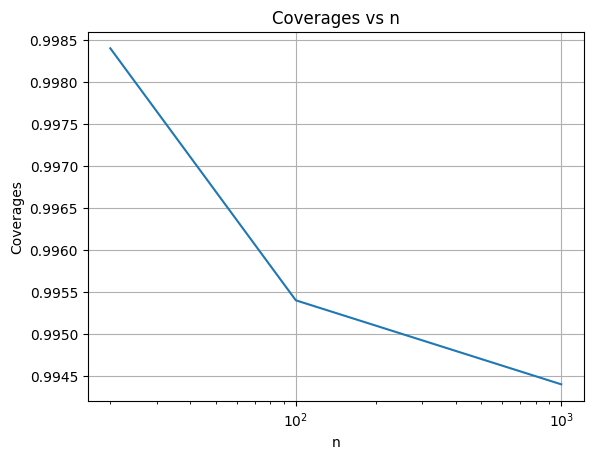

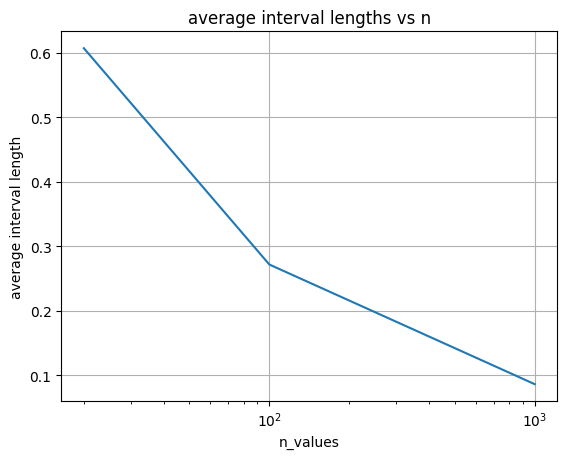

In [46]:
p = 0.35
alpha = 0.05
R = 5000
n_values = [20, 100, 1000]

def hoeffding_interval(data, alpha=0.05):
    n = len(data)
    means = np.mean(data)
    radius = np.sqrt(np.log(2 / alpha) / (2 * n))
    lower = means - radius
    upper = means + radius
    return lower, upper

results = []
coverage = []
avg_length = []


for n in n_values:
    contains = []
    lengths = []
    for _ in range(R):
        data = rng.binomial(1, p, size=n)      # generates n zeros/ones with success probability p_true
        lower, upper = hoeffding_interval(data, 0.05)
        contains.append(lower <= p <=upper)    #should check wheather true probability inside interval
        lengths.append(upper - lower)               #interval length
    
    cov = np.mean(contains)
    avg_len = np.mean(lengths)

    coverage.append(cov)
    avg_length.append(avg_len)

    results.append({
        "n": n,
        "coverage": cov,
        "avg_length": avg_len
    })


print("n values:", n_values)
print("Coverage:", coverage)
print("Average interval lengths:", avg_length)

df_ci = pd.DataFrame(results)
df_ci


# TODO: plot coverage vs n
plt.plot(n_values, coverage)
plt.xscale("log")
plt.xlabel("n")
plt.ylabel("Coverages")
plt.title("Coverages vs n")
plt.grid(True)
plt.show()

# TODO: plot average interval length vs n
plt.plot( n_values, avg_length)
plt.xscale("log")
plt.xlabel("n_values")
plt.ylabel("average interval length")
plt.title("average interval lengths vs n")
plt.grid(True)
plt.show()


## Problem 2 — Classification With Cost

Generate binary classification data.

Tasks:
1. Generate features `x1`, `x2`.
2. Generate target using logistic probability.
3. Fit logistic regression.
4. Predict probabilities.
5. Create cost function:
   - false negative cost = 8
   - false positive cost = 2
6. Find best threshold.
7. Report precision, recall and cost for threshold 0.5 and best threshold.

Hints:
- `prob = 1 / (1 + np.exp(-z))`
- `y = rng.binomial(1, prob)`
- Try `thresholds = np.linspace(0, 1, 101)`.


In [35]:
n = 3000

x1 = rng.normal(size=n)
x2 = rng.normal(size=n)

z = 5 * x1 + 3.9 * x2
prob = 1 / (1 + np.exp(-z))
y = rng.binomial(1, prob)

df_clf = pd.DataFrame({"x1": x1, "x2": x2, "y": y})

X = df_clf[["x1", "x2"]]
y = df_clf["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print(y_proba.shape)

def avg_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    total_cost = 2 * fp + 8 * fn
    return total_cost / len(y_true)

thresholds = np.linspace(0, 1, 101)
costs = []
#costs = np.array([avg_cost(y_test, y_proba, t) for t in thresholds])
for t in thresholds:
    cost = avg_cost(y_test, y_proba, t)
    costs.append(cost)
costs = np.array(costs)

#index of minimum cost
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
print(best_threshold)

def summarize_threshold(threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "cost": avg_cost(y_test, y_proba, threshold)
    }

pd.DataFrame([
    summarize_threshold(0.5),
    summarize_threshold(best_threshold)
])


(600,)
0.13


,threshold,precision,recall,f1,cost
0,0.50,0.907895,0.876190,0.891761,0.613333
1,0.13,0.805699,0.987302,0.887304,0.303333


## Problem 3 — Markov Chain

Use transition matrix:

$$
P =
\begin{pmatrix}
0.8 & 0.2 \\
0.4 & 0.6
\end{pmatrix}
$$

Tasks:
1. Check row sums.
2. Simulate 10,000 steps from state 0.
3. Estimate empirical state frequencies.
4. Approximate stationary distribution by repeated multiplication.
5. Compare simulation and stationary distribution.

Hints:
- Use `rng.choice([0,1], p=P[current_state])`.
- Use `np.bincount(chain, minlength=2) / len(chain)`.
- Distribution update: `pi = pi @ P`.


In [ ]:
P = np.array([
    [0.8, 0.2],
    [0.4, 0.6]
])

# Row sums
print(P.sum(axis=1))
#print(np.sum(P[:1, :]))

T = 10_000
chain = np.zeros(T, dtype=int)
chain[0] = 0

for t in range(1, T):
    current_state = chain[t-1]
    chain[t] = rng.choice([0,1], p=P[current_state])

empirical = np.bincount(chain, minlength=2) / len(chain)
print(empirical)

pi = np.array([1.0, 0.0])
for i in range(10_000):
    pi = pi @ P

print(pi)


1.0
[0.6638 0.3362]
[0.66666667 0.33333333]


## Problem 4 — SVD Compression

Tasks:
1. Generate matrix `A` with shape `(80, 40)`.
2. Compute SVD.
3. Create rank-1, rank-5, rank-10, rank-20 approximations.
4. Calculate Frobenius reconstruction error.
5. Plot error vs rank.

Hints:
- `U, S, Vt = np.linalg.svd(A, full_matrices=False)`
- `A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]`


In [40]:
A = rng.normal(size=(80, 40))

U, S, Vt = np.linalg.svd(A, full_matrices=False)

ranks = [1, 5, 10, 20]
errors = []

for k in ranks:
    A_k = U[:, :k] @np.diag(S[:k]) @Vt[:k, :]
    error = np.linalg.norm(A -A_k, ord="fro")
    errors.append(error)

df_svd = pd.DataFrame({"rank": ranks, "error": errors})
df_svd


,rank,error
0,1,54.941741
1,5,48.033846
2,10,40.306757
3,20,26.299412


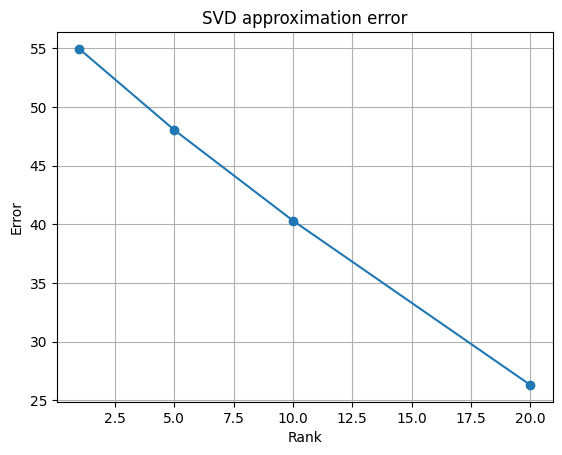

In [41]:
plt.plot(df_svd["rank"], df_svd["error"], marker="o")
plt.xlabel("Rank")
plt.ylabel("Error")
plt.title("SVD approximation error")
plt.grid()
plt.show()


# Day 9 — Final Reflection Questions

1. Which problem was hardest? Second was hardest, its long and also I need to define z by myself
2. Which formulas should you memorize? SVD, markov chain rule calculation
3. Which code templates are reusable? all
4. Which errors did you make? shape of probability prediction in task 2
5. What should you review tomorrow? probabilities, campling, statistical estimation, markov chain



---

<a id="day1"></a>

# Day1

**Source file:** `Day1_Mock_Assignments_1MS041(2).ipynb`



# Day 1 Mock Assignments — Probability & NumPy Foundations

**Course:** 1MS041 Introduction to Data Science  
**Purpose:** Practice for the practical Python re-exam, following Day 1 of the 10-day plan.

Day 1 focus:

- Conditional probability
- Independence and complements
- Binomial/geometric simulations
- Distribution of a transformed random variable
- Monte Carlo approximation
- Hoeffding confidence intervals
- NumPy vectorization and plotting

**Recommended time:** 3.5–4.5 hours  
**Exam-style rule:** Try each problem first without looking at old notebooks or solutions.

## Setup
Run this cell first. Use only standard libraries unless a problem explicitly says otherwise.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

---

# Problem 1 — Independence, Complements and Simulation

Let `A` and `B` be independent events with probabilities

- `P(A) = 0.35`
- `P(B) = 0.60`

## Tasks

1. Compute theoretically:
   - `P(A ∩ B)`
   - `P(Aᶜ ∩ Bᶜ)`
   - `P(Aᶜ)P(Bᶜ)`
2. Simulate `n = 100_000` independent trials where events `A` and `B` occur independently.
3. Estimate the same probabilities from simulation.
4. Write a short conclusion: does the simulation support that complements of independent events are independent?

## Expected skills

- Boolean arrays
- `np.mean`
- Complement using `~`
- Empirical probability estimation

In [3]:
# Problem 1 starter code
p_A = 0.35
p_B = 0.60
n = 100_000

# TODO: theoretical probabilities
p_A_and_B = p_A * p_B
p_Ac_and_Bc = (1-p_A) * (1-p_B) 
p_Ac_times_PBc = p_Ac_and_Bc

print("Theoretical P(A and B):", p_A_and_B)
print("Theoretical P(Ac and Bc):", p_Ac_and_Bc)
print("Theoretical P(Ac)P(Bc):", p_Ac_times_PBc)

# TODO: simulate A and B as Boolean arrays
A = np.random.rand(n) < p_A
B = np.random.rand(n) < p_B
print(np.mean(A))
print(np.mean(B))

# TODO: empirical probabilities
emp_A_and_B = np.mean(A & B)
emp_Ac_and_Bc = np.mean((~A) & (~B))
emp_Ac_times_PBc = np.mean(~A) * np.mean(~B)

print("Empirical P(A and B):", emp_A_and_B)
print("Empirical P(Ac and Bc):", emp_Ac_and_Bc)
print("Empirical P(Ac)P(Bc):", emp_Ac_times_PBc)

Theoretical P(A and B): 0.21
Theoretical P(Ac and Bc): 0.26
Theoretical P(Ac)P(Bc): 0.26
0.34848
0.6016
Empirical P(A and B): 0.20984
Empirical P(Ac and Bc): 0.25976
Empirical P(Ac)P(Bc): 0.25956556799999997


In [10]:
# Problem 1 self-checks
# Run after completing the starter code.
assert abs(p_A_and_B - p_A*p_B) < 1e-12
assert abs(p_Ac_and_Bc - (1-p_A)*(1-p_B)) < 1e-12
assert abs(p_Ac_and_Bc - p_Ac_times_PBc) < 1e-12
assert abs(emp_A_and_B - p_A_and_B) < 0.01
assert abs(emp_Ac_and_Bc - p_Ac_and_Bc) < 0.01
print("Problem 1 checks passed.")

Problem 1 checks passed.


---

# Problem 2 — Conditional Probability with Children

A child has brown hair with probability `p = 1/4`. Assume independence between children and consider a family with 3 children.

## Tasks

1. Compute theoretically:
   - `P(at least 2 brown-haired children | at least 1 brown-haired child)`
   - `P(at least 2 brown-haired children | oldest child has brown hair)`
2. Simulate `n = 200_000` families.
3. Estimate both conditional probabilities from simulation.
4. Explain why the two answers are different.

## Expected skills

- Binomial reasoning
- Conditional probability by filtering arrays
- Boolean masks
- Simulation with shape `(n, 3)`

In [3]:
# Problem 2 starter code
p = 1/4         #probability of brown hair
nfam = 200000
n = 3           #number of children
q = 1-p         # the probability of a child not having brown hair

import math


# P(X=0)        Probability that no child has brown hair
p0 = (3/4)**3

# P(X=1)        Probability that exactly one child has brown hair
p1 = math.comb(3,1) * p * (1-p)**2

# First probability
p_at_least2 = 1 - p0 - p1       #Probability that at least 2 children have brown hair
p_at_least1 = 1 - p0            #Probability that at least 1 child has brown hair


#from scipy.stats import binom
#p_N = lambda k: comb(10,k)*((1-p)**(10-k))*((p)**k)

#Probability of AT LEAST 2 children: P(X >= k)
#prob_at_least_2 = 1 - binom.cdf(2 - 1, n, p)
#print(f"At least {2}: {prob_at_least_2:.4f}")
#Probability of AT LEAST 1 children: P(X >= k)
#prob_at_least_1 = 1 - binom.cdf(1 - 1, n, p)
#print(f"At least {1}: {prob_at_least_1:.4f}")

# TODO: theoretical values
prob_at_least_2_given_at_least_1 = p_at_least2 / p_at_least1
prob_at_least_2_given_oldest_brown1 = 1 - (3/4)**2

print("Theory, given at least one:", prob_at_least_2_given_at_least_1)
print("Theory, given oldest brown:", prob_at_least_2_given_oldest_brown1 - 7/16)
print(type(prob_at_least_2_given_oldest_brown1))

# TODO: simulate families; True = brown hair
families = rng.random((nfam,3)) < p  # shape should be (n, 3)
counts = np.sum(families, axis=1)

# TODO: empirical conditional probabilities
condition = counts >= 1
target = counts >= 2
emp_given_at_least_1 = np.mean(target[condition])

oldest_brown = families[:,0]
emp_given_oldest_brown = np.mean(counts[oldest_brown] >= 2)


print("Empirical, given at least one:", emp_given_at_least_1)
print("Empirical, given oldest brown:", emp_given_oldest_brown)

Theory, given at least one: 0.2702702702702703
Theory, given oldest brown: 0.0
<class 'float'>
Empirical, given at least one: 0.27237172276542354
Empirical, given oldest brown: 0.43930601136636516


In [5]:
# Problem 2 self-checks
assert abs(prob_at_least_2_given_at_least_1 - 10/37) < 1e-12
assert abs(prob_at_least_2_given_oldest_brown1 - 7/16) < 1e-12
assert abs(emp_given_at_least_1 - prob_at_least_2_given_at_least_1) < 0.02
assert abs(emp_given_oldest_brown - prob_at_least_2_given_oldest_brown1) < 0.02
print("Problem 2 checks passed.")

Problem 2 checks passed.


In [ ]:
from scipy.stats import binom
# setting the values
# of n and p
n = 3
p = 0.25
# defining the list of r values
r_values = list(range(n + 1))
# obtaining the mean and variance 
mean, var = binom.stats(n, p)
# list of pmf values
dist = [binom.pmf(r, n, p) for r in r_values ]
print()
# printing the table
print("r\tp(r)")
for i in range(n + 1):
    print(str(r_values[i]) + "\t" + str(dist[i]))
# printing mean and variance
print("mean = "+str(mean))
print("variance = "+str(var))

r	p(r)
0	0.42187499999999994
1	0.4218750000000001
2	0.14062499999999994
3	0.015625
mean = 0.75
variance = 0.5625


---

# Problem 3 — Uniform Distribution on the Unit Disc

Let `(X, Y)` be uniformly distributed on the unit disc

$$
D = \{(x,y): x^2 + y^2 \le 1\}.
$$

Define

$$
R = \sqrt{X^2 + Y^2}.
$$

## Tasks

1. Derive the CDF `F_R(r)` and PDF `f_R(r)` of `R`.
2. Write a function `sample_unit_disc(n, rng)` that samples points uniformly from the unit disc.
3. Use your function to simulate `R` for `n = 100_000`.
4. Plot a histogram of simulated `R` and overlay the theoretical PDF.
5. Verify empirically that `P(R <= 0.5)` is close to the theoretical value.

## Expected skills

- Polar-coordinate simulation
- Transforming uniform random variables
- Histograms with density normalization
- Theoretical vs empirical validation

Theoretical P(R <= 0.5): 0.25
Empirical P(R <= 0.5): 0.24861


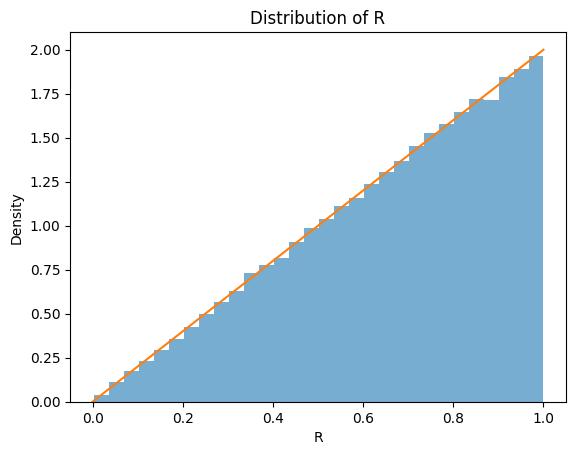

In [ ]:
# Problem 3 starter code

import numpy as np
import matplotlib.pyplot as plt


def sample_unit_disc(n, rng):
    """Return arrays X, Y sampled uniformly from the unit disc."""
    # TODO: use polar coordinates.
    # Hint: angle should be uniform on [0, 2*pi), but radius is not uniform on [0,1].

    # generating random numbers between 0 and 1
    u1 = rng.random(n)
    u2 = rng.random(n)
    
    # calculating radius and angle
    r = np.sqrt(u1)
    theta = 2 * np.pi * u2

    # transforming to carthesian coordinates
    X = r * np.cos(theta)
    Y = r * np.sin(theta)
    return X, Y

n = 100_000
X, Y = sample_unit_disc(n, rng)
R =  np.sqrt(X**2 + Y**2)

# TODO: theoretical P(R <= 0.5)
#theoretical probability = area of small disk/ area of unit disc = pi * 0.5**2 /pi*1**2 =pi/4 /pi =0.25
theory_prob_R_le_05 = 0.25
emp_prob_R_le_05 = np.mean(R <= 0.5)

print("Theoretical P(R <= 0.5):", theory_prob_R_le_05)
print("Empirical P(R <= 0.5):", emp_prob_R_le_05)

# TODO: plot histogram and theoretical PDF f_R(r) = 2r on [0,1]
r= np.linspace(0,1, 200)
plt.hist(R, bins=30, density=True, alpha=0.6)
plt.plot(r, 2*r)
plt.xlabel("R")
plt.ylabel("Density")
plt.title("Distribution of R")
plt.show()

In [16]:
# Problem 3 self-checks
assert X.shape == (n,)
assert Y.shape == (n,)
assert np.all(X**2 + Y**2 <= 1 + 1e-12)
assert abs(theory_prob_R_le_05 - 0.25) < 1e-12
assert abs(emp_prob_R_le_05 - 0.25) < 0.01
print("Problem 3 checks passed.")

Problem 3 checks passed.


---

# Problem 4 — Geometric Distribution and Waiting Times

A fair coin is tossed until the first head appears. Let `X` be the number of tosses required.

## Tasks

1. Derive `E[X]` theoretically.
2. Simulate `n = 100_000` repetitions of this experiment.
3. Estimate the mean and variance of `X`.
4. Plot the empirical PMF for `X = 1, ..., 10` and compare it with the theoretical PMF.
5. Repeat for a biased coin with `P(head) = 0.3`.

## Expected skills

- Geometric distribution
- `rng.geometric`
- Empirical PMF
- Comparing theory and simulation

Theory mean: 2.0
Empirical mean: 1.99345
Theory variance: 2.0
Empirical variance: 1.9948870463704635


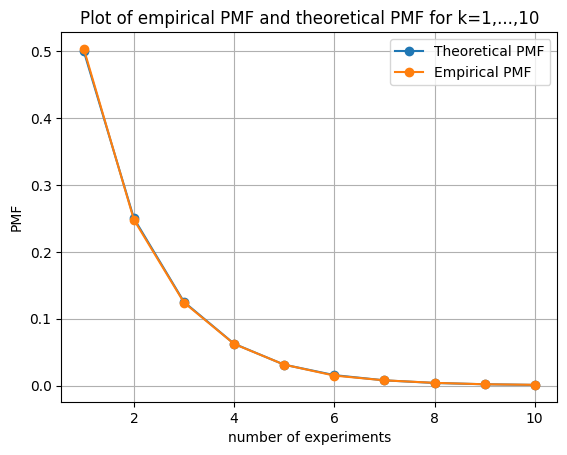

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
# Problem 4 starter code
n = 100_000

# Fair coin
p_head = 0.5

# TODO: theoretical mean and variance for geometric distribution on {1,2,...}
theory_mean = 1 /p_head
theory_var = (1-p_head)/(p_head**2)

# TODO: simulate waiting times
X_wait = rng.geometric(p=p_head, size=n)

emp_mean = np.mean(X_wait)
emp_var = np.var(X_wait, ddof=1)

print("Theory mean:", theory_mean)
print("Empirical mean:", emp_mean)
print("Theory variance:", theory_var)
print("Empirical variance:", emp_var)

# TODO: plot empirical PMF and theoretical PMF for k=1,...,10
k_max=10
# Calculate empirical PMF (Probability Mass Function, simulation frequency between 1 and 10)
empirical_counts = np.bincount(X_wait)[1:k_max+1]
empirical_pmf = empirical_counts / n
# Calculate theoretical PMF
k_values = np.arange(1, k_max + 1)
theoretical_pmf = (1-p_head)**(k_values-1) * p_head

plt.plot(k_values, theoretical_pmf, 'o-', label="Theoretical PMF")
plt.plot(k_values, empirical_pmf, 'o-', label="Empirical PMF")
plt.xlabel("number of experiments")
plt.ylabel("PMF")
plt.title("Plot of empirical PMF and theoretical PMF for k=1,...,10")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Problem 4 self-checks
assert abs(theory_mean - 2.0) < 1e-12
assert abs(theory_var - 2.0) < 1e-12
assert abs(emp_mean - theory_mean) < 0.05
assert abs(emp_var - theory_var) < 0.10
print("Problem 4 checks passed.")

Problem 4 checks passed.


---

# Problem 5 — Hoeffding Confidence Intervals for Bernoulli Data

Let `X_1, ..., X_n` be IID Bernoulli(`p`). Define

$$
\hat p_n = \frac{1}{n}\sum_{i=1}^n X_i
$$

and

$$
\varepsilon_n = \sqrt{\frac{1}{2n}\log\left(\frac{2}{\alpha}\right)}.
$$

Then the Hoeffding confidence interval is

$$
I_n = [\hat p_n - \varepsilon_n, \hat p_n + \varepsilon_n].
$$

## Tasks

1. Implement `hoeffding_interval(data, alpha)`.
2. For `p = 0.4`, `alpha = 0.05`, and `n ∈ {10, 100, 1000, 10000}`, simulate 10,000 datasets for each `n`.
3. Estimate the coverage probability: how often does the interval contain the true `p`?
4. Plot coverage vs sample size using log-scale on x-axis.
5. Plot average interval length vs sample size using log-scale on x-axis.
6. Explain why the interval length decreases as `n` increases.

## Expected skills

- Functions
- Repeated simulations
- Confidence intervals
- Hoeffding inequality
- Plotting on log-scale

n values: [10, 100, 1000, 10000]
Coverage: [np.float64(0.9992), np.float64(0.9953), np.float64(0.9937), np.float64(0.9942)]
Average interval lengths: [np.float64(0.858938816693475), np.float64(0.2716203031481239), np.float64(0.08589388166934753), np.float64(0.02716203031481234)]


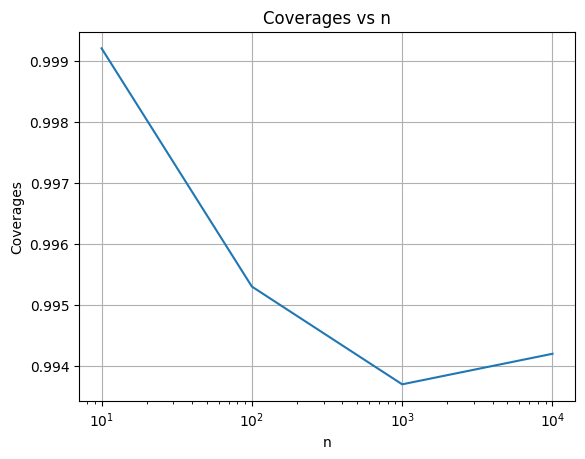

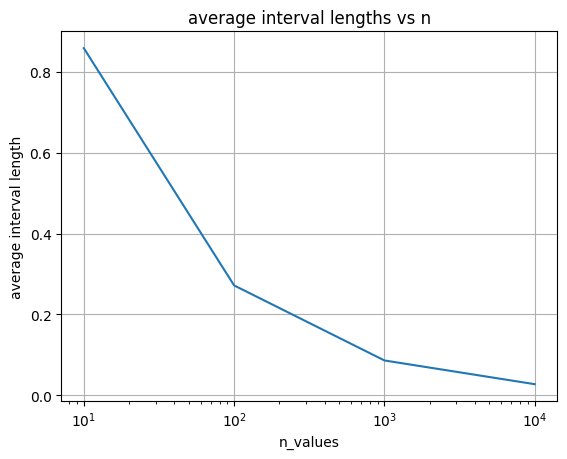

In [47]:
# Problem 5 starter code
import numpy as np

def hoeffding_interval(data, alpha=0.05):
    """Return lower and upper Hoeffding confidence interval bounds for Bernoulli data."""
    n = len(data)
    p_hat = np.mean(data)
    eps = np.sqrt(np.log(2.0 /alpha ) / (2.0 * n))
    lower = p_hat - eps
    upper = p_hat + eps
    return lower, upper
 
p_true = 0.4
alpha = 0.05
n_values = [10, 100, 1000, 10000]
trials = 10_000


coverages = []
avg_lengths = []

# TODO: simulation study
for n in n_values:
    contains = []
    lengths = []
    for _ in range(trials):
        data = rng.binomial(1, p_true, size=n)      # generates n zeros/ones with success probability p_true
        lower, upper = hoeffding_interval(data, alpha)
        contains.append(lower <= p_true <=upper)    #should check wheather true probability inside interval
        lengths.append(upper - lower)               #interval length
    coverages.append(np.mean(contains))             #Coverage probability
    avg_lengths.append(np.mean(lengths))            #Average interval width

print("n values:", n_values)
print("Coverage:", coverages)
print("Average interval lengths:", avg_lengths)

# TODO: plot coverage vs n
plt.plot(n_values, coverages)
plt.xscale("log")
plt.xlabel("n")
plt.ylabel("Coverages")
plt.title("Coverages vs n")
plt.grid(True)
plt.show()
# TODO: plot average interval length vs n
plt.plot( n_values, avg_lengths)
plt.xscale("log")
plt.xlabel("n_values")
plt.ylabel("average interval length")
plt.title("average interval lengths vs n")
plt.grid(True)
plt.show()

6. Explain why the interval length decreases as `n` increases.
Answer: The interval length decreases as n increases because larger sample sizes reduce statistical uncertainty and provide a more accurate estimate of the true probability.

In [48]:
# Problem 5 self-checks
sample = np.array([0, 1, 1, 0, 1])
lower, upper = hoeffding_interval(sample, alpha=0.05)
expected_eps = np.sqrt((1/(2*len(sample))) * np.log(2/0.05))
assert abs(lower - (sample.mean() - expected_eps)) < 1e-12
assert abs(upper - (sample.mean() + expected_eps)) < 1e-12
assert len(coverages) == len(n_values)
assert len(avg_lengths) == len(n_values)
assert all(c >= 0.90 for c in coverages), "Coverage should usually be high for Hoeffding intervals."
print("Problem 5 checks passed.")

Problem 5 checks passed.


---

# Problem 6 — Mini Exam Challenge

This is a timed integrated problem. Try to finish in **60 minutes**.

A disease occurs in a population with unknown probability `p`. You observe `n` people and record `1` if the person has the disease and `0` otherwise.

You suspect that the disease rate may have changed from historical value `p_old = 0.4` to new value `p_new = 0.5`.

## Tasks

1. Generate Bernoulli samples using `p_new = 0.5` for `n ∈ {10, 100, 1000, 10000}`.
2. Build Hoeffding intervals from the generated data.
3. Estimate how often the interval contains `p_new`.
4. Estimate how often the interval contains `p_old`.
5. Interpret the result: as `n` grows, does it become easier to detect the change?

## Expected skills

- Simulation design
- Decision logic
- Confidence intervals
- Interpretation under distribution shift

Contains new p=0.5: [np.float64(0.9981), np.float64(0.9948), np.float64(0.9927), np.float64(0.9931)]
Contains old p=0.4: [np.float64(0.9894), np.float64(0.7586), np.float64(0.0001), np.float64(0.0)]


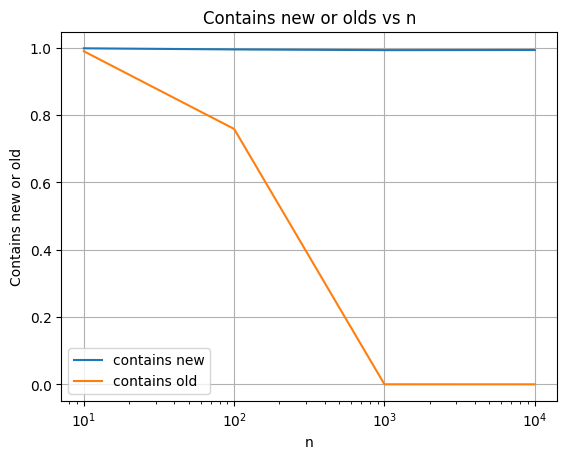

In [53]:
import numpy as np
# Problem 6 starter code
p_old = 0.4
p_new = 0.5
alpha = 0.05
n_values = [10, 100, 1000, 10000]
trials = 10_000

def hoeffding_interval(data, alpha=0.05):
    """Return lower and upper Hoeffding confidence interval bounds for Bernoulli data."""
    n = len(data)
    p_hat = np.mean(data)
    eps = np.sqrt(np.log(2.0 /alpha ) / (2.0 * n))
    lower = p_hat - eps
    upper = p_hat + eps
    return lower, upper

contains_new = []
contains_old = []

# TODO: complete simulation
for n in n_values:
    new_hits = []
    old_hits = []
    for _ in range(trials):
        data = rng.binomial(1, p_new, size=n)      # generates n zeros/ones with success probability p_new
        lower, upper = hoeffding_interval(data, alpha)
        new_hits.append(lower <= p_new <=upper)
        old_hits.append(lower <= p_old <=upper)
    contains_new.append(np.mean(new_hits))
    contains_old.append(np.mean(old_hits))

print("Contains new p=0.5:", contains_new)
print("Contains old p=0.4:", contains_old)

# TODO: plot both curves against n
plt.plot(n_values, contains_new, label="contains new")
plt.plot(n_values, contains_old, label="contains old")
plt.xscale("log")
plt.xlabel("n")
plt.ylabel("Contains new or old")
plt.title("Contains new or olds vs n")
plt.grid(True)
plt.legend()
plt.show()


5. Interpret the result: as `n` grows, does it become easier to detect the change? ANSWER: As n grows, statistical uncertainty decreases and the confidence intervals become narrower. Since the true data-generating probability is p_new = 0.5, the intervals usually contain p_new. However, for large n they no longer contain p_old = 0.4, so the change becomes easier to detect.

---

# Reflection Checklist

Before ending Day 1, answer these questions in markdown:

1. Which problem took the longest and why?
2. Which NumPy operations did you need to look up?
3. Can you explain Hoeffding intervals without using code?
4. Can you simulate conditional probabilities confidently?
5. What will you revise tomorrow before starting Day 2?

In [ ]:
# Optional: write your short notes here as comments.
# 1.Conditional probability with children. Hard to undestand the logic of the calculation
# 2.Binomial, plt.hist(), plt.plot(), rng.random().
# 3.Difficult
# 4.not sure
# 5.yes

---

# Optional Solution Hints

Use this section only after making a serious attempt.

- Complements of independent events: use `~A`, `~B` for Boolean arrays.
- Children problem: simulate with `rng.random((n, 3)) < p`.
- Unit disc: use `theta = rng.uniform(0, 2*np.pi, n)` and `r = np.sqrt(rng.uniform(0, 1, n))`.
- Geometric waiting time: use `rng.geometric(p_head, size=n)`.
- Hoeffding interval: `eps = np.sqrt((1/(2*n))*np.log(2/alpha))`.
- Coverage: count how often `lower <= p_true <= upper`.


---

<a id="day2"></a>

# Day2

**Source file:** `Day2_Sampling_Random_Variables(2).ipynb`



# Day 2 Mock Assignments — Sampling & Random Variable Generation

Topics:
- CDF/PDF reasoning
- inverse transform sampling
- rejection sampling
- simulation validation
- empirical probability estimation

Use only Python, NumPy, pandas, matplotlib, and scipy/sklearn if needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Problem 1 — Inverse Transform Sampling

Let random variable X have density:

$$
f(x)=2x, \quad 0 \le x \le 1
$$

Tasks:
1. Derive the CDF theoretically.
2. Derive the inverse CDF.
3. Generate `n = 100_000` samples using inverse transform sampling.
4. Plot histogram and compare visually with theoretical PDF.
5. Estimate empirical mean and compare with theoretical mean.

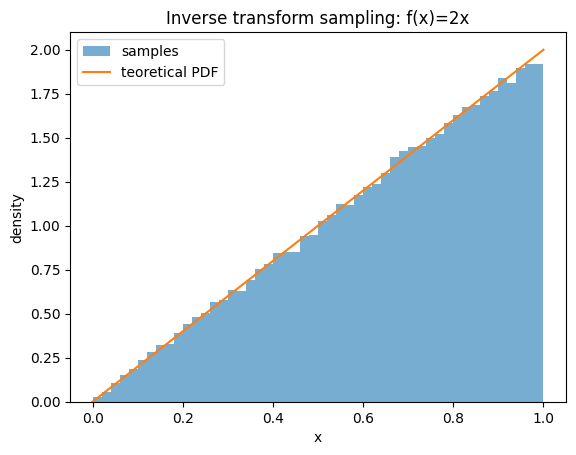

theoretical mean = 0.6666666666666666
empirical mean = 0.6649966505189862


In [11]:
# TODO: derive and implement inverse CDF sampler
import numpy as np
import matplotlib.pyplot as plt

# PDF: f(x)=2x on [0,1] Probability Density Function

#The Cumulative Distribution Function (CDF) is found by integrating the PDF
#F(x)= integral from 0 to x of 2x dx= x^2

#Inverse CDF
#u = x^2  =>  x = sqrt(u)
n = 100000

u= np.random.uniform(0, 1, size=n)
samples= np.sqrt(u)

x= np.linspace(0,1,200)
pdf= 2 * x

plt.hist(samples, bins=50, density=True, alpha=0.6, label="samples")
plt.plot(x,pdf,label="teoretical PDF")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Inverse transform sampling: f(x)=2x")
plt.legend()
plt.show()

emp_mean=np.mean(samples)

# theoretical mean: E[X] = integral_0^1 x * 2x dx = 2/3
theory_mean = 2 / 3

print("theoretical mean =", theory_mean)
print("empirical mean =", emp_mean)



## Problem 2 — Rejection Sampling

Target density:

$$
p(x)=\frac{1}{2}\cos(x), \quad -\pi/2 < x < \pi/2
$$

Tasks:
1. Use Uniform(-pi/2, pi/2) as proposal distribution.
2. Find constant M such that p(x) <= M g(x).
3. Implement rejection sampling.
4. Estimate acceptance rate.
5. Plot accepted samples.

In [15]:
import numpy as np
from scipy.optimize import minimize_scalar
# TODO: rejection sampler

def p(x):                   #target distribution
    return 0.5 * np.cos(x)

#find M using Uniform Probality Distribution 
#1. Find the PDF of the interval pi/2-(-pi/2)=pi
# g(x)=1/pi 
#2.Find maximum of p(x)/g(x)=0.5cos(x)/ 1/pi= pi/2 cos(x)
#max value of cos(x)=1
#3.Result M=pi/2=1.571
#M = np.pi / 2
M= None
if M is None: # finding max of a function
    from scipy.optimize import minimize_scalar
    res = minimize_scalar(lambda x: -p(x), bounds=(-np.pi/2, np.pi/2), method='bounded')
    M = p(res.x)
print("M=", M)

def sample_rejection(n=1):
    samples = []
    attempts = 0
    
    while len(samples) < n:
        #generate candidate
        x = np.random.uniform(- np.pi / 2, np.pi / 2)
    
        # uniform for accept/reject
        u = np.random.uniform(0, 1)

        if (u <= p(x)/M):
            samples.append(x)

        attempts += 1

    return np.array(samples), attempts

samples, attempts = sample_rejection(50_000)
print("Acceptance rate:", len(samples) / attempts)


M= 0.5
Acceptance rate: 0.6374298827129016


## Problem 3 — Discrete Sampling

Let Y take values 0, 1, 2, 3 with probabilities 0.1, 0.3, 0.2, 0.4.

Tasks:
1. Simulate `n = 100_000` values.
2. Estimate probability mass function empirically.
3. Plot empirical vs theoretical probabilities.
4. Compute empirical mean and variance.

[2 3 3 ... 3 2 2]
[0.09832 0.29698 0.20097 0.40373]


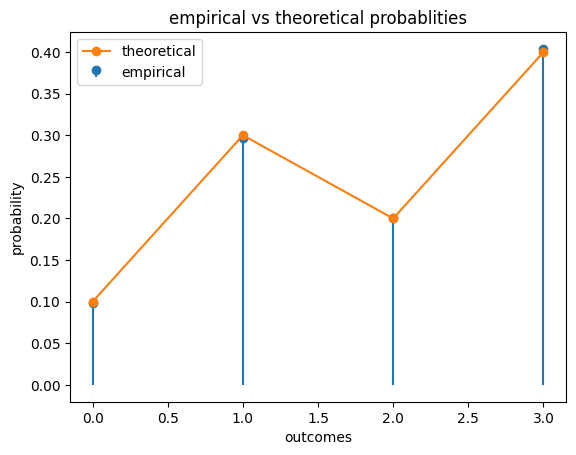

empirical mean = 1.91011
variance = 1.0859097879000001


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

values = np.array([0, 1, 2, 3])
probs = np.array([0.1, 0.3, 0.2, 0.4])

samples = np.random.choice(values, size=100000, p=probs)
print(samples)

#Estimate PMF empirical
# Calculate unique values and their absolute counts
outcomes, counts = np.unique(samples, return_counts=True)
# Convert counts to probabilities (this creates the PMF)
pmf = counts / len(samples)
print(pmf)

# theoretical PMF
theoretical_pmf = probs

#Plot empirical vs theoretical probablities
plt.stem(outcomes, pmf, basefmt=" ", label="empirical")
plt.plot(values, theoretical_pmf, 'o-', label="theoretical")
plt.xlabel("outcomes")
plt.ylabel("probability")
plt.title("empirical vs theoretical probablities")
plt.legend()
plt.show()

#Compute empirical mean and variance
emp_mean=np.mean(samples)
variance=np.var(samples)
print("empirical mean =", emp_mean)
print("variance =", variance)


---

<a id="day3"></a>

# Day3

**Source file:** `Day3_Estimation_Confidence_Intervals_WITH_HINTS(3).ipynb`



# Day 3 Mock Assignments — Estimation & Confidence Intervals

Topics:
- estimator distribution
- bias, variance, standard error, MSE
- simulation studies
- Hoeffding confidence intervals

## General hints and information

* Try to complete every task, even if you are uncertain.
* Comment your code so that your reasoning is visible.
* Most tasks can be solved by simulating many independent repetitions and then summarizing the results.
* Use clear variable names such as `estimates`, `bias`, `se`, `mse`, `coverage`, and `lengths`.
* When asked to compare with theory, print both simulated and theoretical values in the same table.
* Before plotting, check that the arrays you plot have the same length.
* For free-text explanations, focus on why the result happens, not only what the number is.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Problem 1 — Maximum Estimator

Let $X_1,\ldots,X_n$ be IID $\mathrm{Uniform}(0, 	heta)$. Let

$$
\hat	heta = \max(X_1,\ldots,X_n).
$$

Use $	heta = 5$.

Tasks:
1. Simulate $\hat	heta$ for `n = 5, 10, 50, 100`.
2. Estimate bias, standard error and MSE by simulation.
3. Compare with theoretical formulas.
4. Plot MSE as a function of `n`.

**Hints:**

* For each value of `n`, generate an array with shape `(R, n)`.
* Each row should represent one simulated experiment.
* Use `np.max(samples, axis=1)` to compute one estimator value per row.
* Bias is approximately `np.mean(estimates) - theta`.
* Standard error of the estimator is approximately `np.std(estimates, ddof=1)`.
* MSE is approximately `np.mean((estimates - theta)**2)`.
* The theoretical expectation is

$E[\hat{\theta}] = \frac{n}{n+1}\theta$

* Therefore the theoretical bias is

$\mathrm{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta = -\frac{\theta}{n+1}$

* Store your results in a list of dictionaries and convert it to a `pandas.DataFrame` for easier comparison.


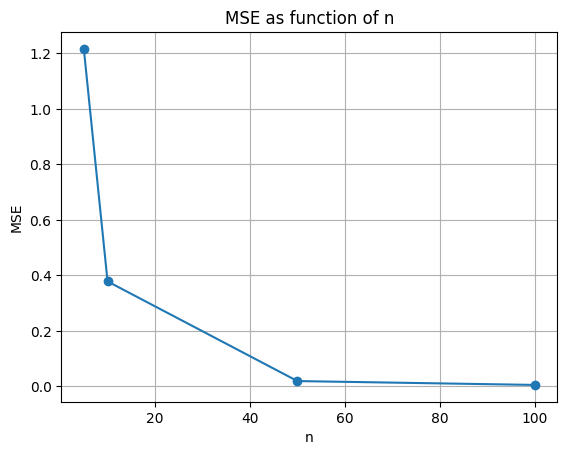

In [ ]:
theta = 5
n_values = [5, 10, 50, 100]
R = 20_000

# Part 1
# For each n, simulate R experiments from Uniform(0, theta).
# Hint: samples = rng.uniform(0, theta, size=(R, n))
experiment = []
for n in n_values:
    samples = rng.uniform(0, theta, size=(R, n))
    experiment.append(samples)
    #print(experiment)


# Part 2
# For each experiment, compute theta_hat = max(sample).
# Hint: estimates = np.max(samples, axis=1)
estimates = []
for exp in experiment:
    estim = np.max(exp, axis=1)
    estimates.append(estim)
    #print(estimates)

# Part 3
# Compute simulated bias, standard error, and MSE.
# Hint:
# bias_sim = np.mean(estimates) - theta
# se_sim = np.std(estimates, ddof=1)
# mse_sim = np.mean((estimates - theta)**2)
results = []

for n, est in zip(n_values, estimates):
    bias_sim = np.mean(est) - theta
    se_sim = np.std(est, ddof=1)
    mse_sim = np.mean((est - theta)**2)
    results.append({
        "n": n,
        "bias_sim": bias_sim,
        "se_sim": se_sim,
        "mse_sim": mse_sim,

    })
    #print(results)
    df = pd.DataFrame(results)


# Part 4
# Compare with theoretical formulas.
# Hint:
# expected_theory = n / (n + 1) * theta
# bias_theory = expected_theory - theta
for n in n_values:
    expected_theory = n / (n + 1) * theta
    bias_theory = expected_theory - theta
    #print(expected_theory)
    #print(bias_theory)

# Part 5
# Plot MSE as a function of n.
# Hint: after storing results in a DataFrame df, use plt.plot(df["n"], df["mse_sim"], marker="o")
plt.plot(df["n"], df["mse_sim"], marker="o")
plt.xlabel("n")
plt.ylabel("MSE")
plt.title("MSE as function of n")
plt.grid(True)
plt.show()
# TODO


## Problem 2 — Hoeffding Confidence Interval

Let $X_1,\ldots,X_n$ be IID $\mathrm{Bernoulli}(p)$, where $p = 0.4$.

Tasks:
1. Implement a Hoeffding confidence interval.
2. Estimate coverage for `n = 10, 100, 1000, 10000`.
3. Plot coverage.
4. Plot interval length.

**Hints:**

* For Bernoulli data, the sample mean estimates $p$.
Hoeffding's inequality gives a radius

$$
\varepsilon = \sqrt{\frac{\log(2/\alpha)}{2n}}
$$

The confidence interval is

$$
[\bar X - \varepsilon,\ \bar X + \varepsilon]
$$

* Since probabilities cannot be below 0 or above 1, clip the interval to `[0, 1]`.
* Coverage means: how often the interval contains the true value `p`.
* In each repetition, generate new Bernoulli data, compute the interval, and check whether `lower <= p <= upper`.
* Interval length is `upper - lower`.


[0.         0.07053059 0.07053059 ... 0.         0.         0.17053059] [0.72946941 0.92946941 0.92946941 ... 0.82946941 0.72946941 1.        ]
[]
[]
0.7707867843013506
[{'n': 10, 'coverage': np.float64(0.9988), 'avg_length': np.float64(0.7707867843013506)}]
[0.27418985 0.26418985 0.29418985 ... 0.24418985 0.30418985 0.26418985] [0.54581015 0.53581015 0.56581015 ... 0.51581015 0.57581015 0.53581015]
[]
[]
0.2716203031481239
[{'n': 10, 'coverage': np.float64(0.9988), 'avg_length': np.float64(0.7707867843013506)}, {'n': 100, 'coverage': np.float64(0.9946), 'avg_length': np.float64(0.2716203031481239)}]
[0.35405306 0.33605306 0.37905306 ... 0.34405306 0.35405306 0.38705306] [0.43994694 0.42194694 0.46494694 ... 0.42994694 0.43994694 0.47294694]
[]
[]
0.08589388166934753
[{'n': 10, 'coverage': np.float64(0.9988), 'avg_length': np.float64(0.7707867843013506)}, {'n': 100, 'coverage': np.float64(0.9946), 'avg_length': np.float64(0.2716203031481239)}, {'n': 1000, 'coverage': np.float64(0.994),

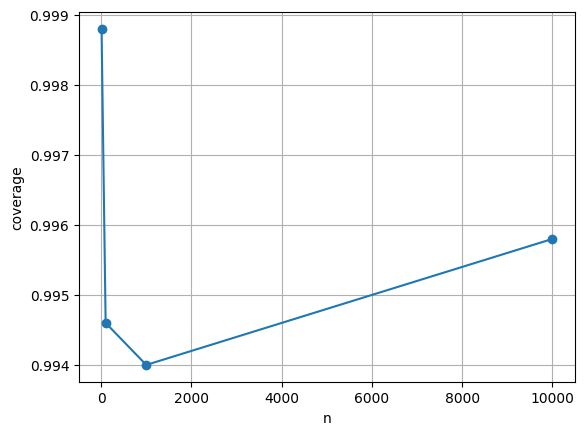

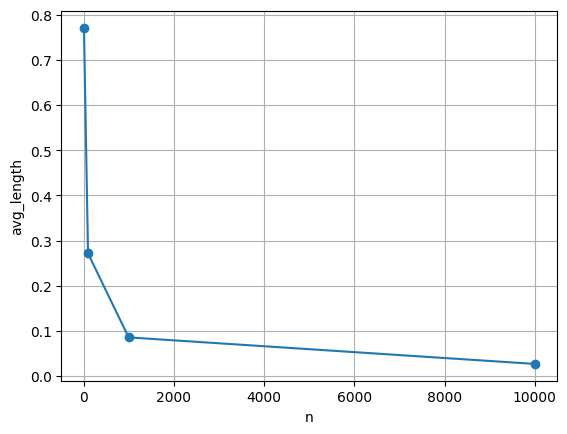

In [58]:
def hoeffding_interval(data, alpha=0.05):
    # data is a numpy array of 0/1 Bernoulli observations
    # Return lower and upper bounds of the Hoeffding confidence interval.
    # Hint:
    #n = len(data)
    n = data.shape[1]
    mean = np.mean(data, axis=1)
    radius = np.sqrt(np.log(2 / alpha) / (2 * n))
    lower = np.maximum(0, mean - radius)
    upper = np.minimum(1, mean + radius)
    return lower, upper
    #pass

p = 0.4
alpha = 0.05
n_values = [10, 100, 1000, 10000]
R = 5000

# Part 1
# For each n, repeat the experiment R times.
# Hint: data = rng.binomial(1, p, size=n)
data_all = []
contains_list = []
length_list = []
results = []
for n in n_values:
    data = rng.binomial(1, p ,size=(R,n))
                   
# Part 2
# Compute the confidence interval and check if it contains p.
# Hint: contains_true_p = lower <= p <= upper
    low, upp = hoeffding_interval(data, alpha=alpha)
    #contains_true_p = low <= p <= upp
    contains_true_p = (low <= p) & (p <= upp)
    print(low,upp)
    print(contains_list)
    print(length_list)
# Part 3
# Estimate coverage as the mean of True/False values.
# Hint: coverage = np.mean(contains_list)
    coverage = np.mean(contains_true_p)
    #coverage = np.mean(contains_list)
# Part 4
# Estimate average interval length.
# Hint: avg_length = np.mean(length_list)
    #avg_length = np.mean(length_list)
    avg_length = np.mean(upp-low)
    results.append({
             "n": n,
             "coverage": coverage,
             "avg_length": avg_length
            })
    print(avg_length)
    print(results)

df = pd.DataFrame(results)

# Part 5
# Plot coverage and average length as functions of n.
plt.plot(df["n"], df["coverage"], marker="o")
plt.xlabel("n")
plt.ylabel("coverage")
plt.grid()
plt.show()
plt.figure()

plt.plot(df["n"], df["avg_length"], marker="o")
plt.xlabel("n")
plt.ylabel("avg_length")
plt.grid()
plt.show()
# TODO


## Problem 3 — Change Detection Simulation

Assume the old value was $p = 0.4$, but the true value changes to $p = 0.5$.

Tasks:
1. Generate data from `p = 0.5`.
2. Construct a Hoeffding interval from observed data.
3. Estimate how often the interval contains the old value `p = 0.4`.
4. Estimate how often the interval contains the new value `p = 0.5`.
5. Explain the difference.

**Hints:**

* The data should be generated from `new_p`, not from `old_p`.
* Reuse your `hoeffding_interval` function from Problem 2.
* In each repetition, compute two checks:
  * `lower <= old_p <= upper`
  * `lower <= new_p <= upper`
* The interval should contain `new_p` approximately at the nominal confidence level.
* The interval should contain `old_p` less often when `n` becomes large, because the data are generated from `new_p = 0.5`.
* This task illustrates how confidence intervals can be used to detect whether an old parameter value is still plausible.


In [68]:
old_p = 0.4
new_p = 0.5
alpha = 0.05
n_values = [10, 100, 1000, 10000]
R = 5000

def hoeffding_interval(data, alpha=0.05):
    n = data.shape[1]
    mean = np.mean(data, axis=1)
    radius = np.sqrt(np.log(2 / alpha) / (2 * n))
    lower = np.maximum(0, mean - radius)
    upper = np.minimum(1, mean + radius)
    return lower, upper

# Part 1
# Generate Bernoulli samples using new_p.
# Hint: data = rng.binomial(1, new_p, size=n)
results = []
for n in n_values:
    data = rng.binomial(1, new_p, size=[R,n])
    # Part 2 Construct a Hoeffding confidence interval.
    lower, upper = hoeffding_interval(data, alpha=alpha)
    # Part 3 Check whether the interval contains old_p.
    contains_old = (lower <= old_p)&(old_p<= upper) 
    coverage_old = np.mean(contains_old)
    # Part 4 contains_new = lower <= new_p <= upper
    contains_new = (lower <= new_p)&(new_p<= upper) 
    coverage_new = np.mean(contains_new)
    # Part 5 Summarize the simulation results in a DataFrame.
    results.append({
        "n":n,
        "coverage_old": coverage_old,
        "coverage_new": coverage_new
    })

df = pd.DataFrame(results)
print(df)

#Explain the difference: The interval should contain old_p less often when `n` becomes large, because the data are generated from new_p = 0.5


# TODO
#plt.plot(df["n"], df["coverage_old"],df["coverage_new"], marker="o")

       n  coverage_old  coverage_new
0     10        0.9854        0.9978
1    100        0.7610        0.9930
2   1000        0.0002        0.9938
3  10000        0.0000        0.9940


# Day 3 — Review Questions, Self-Test, and Exam Preparation

## Conceptual Questions

1. What is an estimator?
2. What is the difference between bias, standard error, variance, and MSE?
3. Why is $\max(X_1,\ldots,X_n)$ a natural estimator for $	heta$ in a Uniform$(0,	heta)$ model?
4. Is the maximum estimator biased or unbiased?
5. Why does the bias decrease when `n` increases?
6. What does Hoeffding's inequality control?
7. What does confidence interval coverage mean?
8. Why does the Hoeffding interval become shorter when `n` increases?
9. Why can an interval contain the old value `p = 0.4` for small `n`, even if the true value is `p = 0.5`?
10. Why does the old value become less plausible for larger `n`?

---

## Mini Self-Test

### Problem 1

Given $	heta = 5$ and $n = 10$:

1. What is the theoretical value of $E[\hat	heta]$?
2. What is the theoretical bias?
3. Should the MSE increase or decrease as `n` grows?
4. Why do we simulate many repetitions `R`?

### Problem 2

1. Write the Hoeffding radius formula from memory.
2. What happens to the interval radius when `n` increases?
3. Why do we clip the interval to `[0, 1]`?
4. What does 95% coverage mean in a simulation?

### Problem 3

1. Which parameter should be used to generate the data: `old_p` or `new_p`?
2. Which value should the interval contain more often for large `n`?
3. How can confidence intervals be used for change detection?

---

## Exam-style Implementation Checklist

Before submitting, check:

- Did you use the random generator `rng` consistently?
- Did you simulate `R` independent repetitions?
- Did you compute one estimate per repetition?
- Did you store the results clearly, preferably in a DataFrame?
- Did you plot the correct variable on the x-axis and y-axis?
- Did you compare empirical and theoretical results where requested?
- Did you explain the interpretation in words?

---

## Key Takeaways

- Simulation can approximate the distribution of an estimator.
- Bias measures systematic error: $E[\hat	heta] - 	heta$.
- Standard error measures variability of the estimator.
- MSE combines variance and squared bias.
- Hoeffding intervals give finite-sample probability bounds for bounded random variables.
- Larger sample sizes usually give shorter confidence intervals.
- Confidence intervals can help decide whether an old parameter value is still plausible.



---

<a id="day4"></a>

# Day4

**Source file:** `Day4_Linear_Regression_Data_Pipelines_WITH_HINTS.ipynb`



# Day 4 Mock Assignments — Linear Regression & Data Pipelines

Topics:
- synthetic data generation
- feature engineering
- train/test split
- linear regression with NumPy / scikit-learn
- MAE, MSE, RMSE, $R^2$
- simple data pipeline thinking

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Problem 1 — Synthetic Housing Regression

You simulate a simple housing dataset.

Assume the true model is:

$$
price = 50 + 3.0 \cdot area + 20 \cdot rooms + \varepsilon
$$

where noise is normal with mean 0 and standard deviation 30.

Tasks:
1. Generate `n = 1000` observations.
2. Create a `pandas.DataFrame`.
3. Split into train and test data.
4. Fit a linear regression model.
5. Estimate coefficients.
6. Evaluate MAE, MSE, RMSE and $R^2$ on test data.
7. Compare estimated coefficients with true coefficients.

Hints:
- Use `rng.normal(...)`.
- Use `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `X` should contain columns `area` and `rooms`.
- `model.coef_` gives coefficients.
- `model.intercept_` gives intercept.
- RMSE is `np.sqrt(MSE)`.


In [2]:
n = 1000

# Part 1
# Generate features.
# Hint: area can be uniform between 30 and 200.
# Hint: rooms can be integers between 1 and 7.
results1 = []

area = rng.uniform(30,200, size=n)
rooms = rng.integers(1,8, size=n)
print("area:", area[5], "rooms:", rooms[5])

# Generate noise.
# Hint: noise = rng.normal(0, 30, size=n)
noise = rng.normal(0, 30, size=n)
print("noise:", noise[5])

# Generate target variable.
price = []
for i in range (0,n): 
    price = 50 + 3.0*area[i] + 20*rooms[i] + noise[i]
    results1.append({
        "n": n,
        "area": area[i],
        "rooms": rooms[i],
        "price": price
    })

# Part 2
# Create DataFrame with columns: area, rooms, price.
df = pd.DataFrame(results1)

# Check first rows.
print(df.head())

# Part 3
# Split X and y.
X = df[['area','rooms']].to_numpy(dtype='float64')
y = df['price'].to_numpy(dtype='float64')


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#display

#print("Columns:",df.columns.tolist())
#print("X", X)
#print("Y:", y)

# Part 4
# Fit linear regression.
model = LinearRegression()  #initialize linear regression model
model.fit(X_train, y_train)

# Part 5
# Print estimated intercept and coefficients.
print(model.intercept_)
print(model.coef_)

# Part 6
# Predict on test data.
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

results = [{
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}]

res= pd.DataFrame(results)
print(res)


area: 195.8557997782485 rooms: 1
noise: 1.207695060013886
      n        area  rooms       price
0  1000  161.572528      7  703.606402
1  1000  104.609335      1  362.089673
2  1000  175.961646      3  612.272162
3  1000  148.552565      4  589.448873
4  1000   46.010149      6  337.687045
44.99738941126611
[ 2.99579942 20.62626688]
         MAE         MSE       RMSE       R2
0  23.401355  833.223129  28.865605  0.96766


## Problem 2 — Feature Engineering

Create a better model by adding engineered features.

Tasks:
1. Add `area_per_room = area / rooms`.
2. Add `large_house = 1` if area is greater than 120, otherwise 0.
3. Fit a new linear regression model.
4. Compare metrics with Problem 1.
5. Explain whether the new features helped.

Hints:
- Use `np.where(condition, 1, 0)`.
- Keep the same train/test split idea.
- Store old and new metrics in one DataFrame.


In [24]:
# Part 1
df["area_per_room"] = area / rooms
df["large_house"] = np.where(area > 120, 1, 0)

# Part 2
features = ["area", "rooms", "area_per_room", "large_house"]
X = df[features]
y = df['price'].to_numpy(dtype='float64')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Part 3
model2 = LinearRegression()
model2.fit(X_train,y_train)

y_pred2 = model2.predict(X_test)

# Part 4
mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test, y_pred)

comparison = [
    {"model": "basic", "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2},
    {"model": "engineered", "MAE": mae2, "MSE": mse2, "RMSE": rmse2, "R2": r2_2},
]

pd.DataFrame(comparison)




,model,MAE,MSE,RMSE,R2
0,basic,23.619382,881.06328,29.682710,0.967053
1,engineered,23.600579,877.80805,29.627826,0.967053


Explain whether new features helped: The engineered features helped only slightly. MAE, MSE and RMSE became a little smaller, but R² stayed almost the same. This means the original features already explained most of the target variable.

## Problem 3 — Data Pipeline Function

Create a reusable function.

Tasks:
1. Write a function `run_regression_pipeline(df, features, target)`.
2. Inside the function:
   - split data
   - fit model
   - predict
   - calculate metrics
   - return dictionary with metrics
3. Run the function for:
   - basic features
   - engineered features

Hints:
- Function should return one dictionary.
- Include `features` as text in result for easier comparison.
- Use `", ".join(features)` to convert list of column names to text.


In [26]:
def run_regression_pipeline(df, features, target):
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "features": ", ".join(features),
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results = []
results.append(run_regression_pipeline(df, ["area", "rooms"], "price"))
results.append(run_regression_pipeline(df, ["area", "rooms", "area_per_room", "large_house"], "price"))

pd.DataFrame(results)


,features,MAE,MSE,RMSE,R2
0,"area, rooms",23.619382,881.06328,29.682710,0.967053
1,"area, rooms, area_per_room, large_house",23.600579,877.80805,29.627826,0.967175


# Day 4 — Review Questions and Mini Exam

## Conceptual Questions

1. What is the purpose of a train/test split?
2. What is the difference between MAE and MSE?
3. Why is RMSE easier to interpret than MSE?
4. What does $R^2$ measure?
5. Why can feature engineering improve a model?
6. What is overfitting?
7. What is a data pipeline?

## Mini Exam Task

Create a new synthetic dataset with:
- one numerical feature
- one categorical-like feature encoded as 0/1
- one target variable

Fit linear regression and report:
- coefficients
- MAE
- MSE
- RMSE
- $R^2$

Write 3 short sentences explaining the results.



---

<a id="day5"></a>

# Day5

**Source file:** `Day5_Logistic_Regression_Classification_WITH_HINTS.ipynb`



# Day 5 Mock Assignments — Logistic Regression & Classification

Topics:
- binary classification
- logistic regression
- train/test split
- probabilities and thresholds
- confusion matrix
- precision, recall, F1
- expected cost

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

## Problem 1 — Battery Health Classification

You classify whether a battery is unhealthy.

Features:
- `age_months`
- `cycles`
- `avg_temperature`

Target:
- `unhealthy = 1` means battery has high failure risk
- `unhealthy = 0` means battery is normal

Tasks:
1. Generate synthetic data.
2. Create target probabilities using a logistic formula.
3. Generate binary target using `rng.binomial`.
4. Split data.
5. Fit logistic regression.
6. Predict probabilities.
7. Predict labels using threshold 0.5.
8. Calculate accuracy, precision, recall and F1.

Hints:
- Logistic function: `1 / (1 + np.exp(-z))`
- Use `model.predict_proba(X_test)[:, 1]` for probability of class 1.
- Precision answers: when model predicts 1, how often is it correct?
- Recall answers: from all true 1 cases, how many did model find?


In [ ]:
n = 2000

age_months = rng.integers(1, 72, size=n)
cycles = rng.integers(50, 1500, size=n)
avg_temperature = rng.normal(30, 6, size=n)

# Part 2
# Create linear score z.
# Hint: higher age, cycles and temperature should increase risk.
z = (
    0.04 * age_months
    + 0.003 * cycles
    + 0.08 * avg_temperature
    - 8
)

prob_unhealthy = 1 / (1 + np.exp(-z))

# Part 3
unhealthy = rng.binomial(1, prob_unhealthy, size=n)

df = pd.DataFrame({
    "age_months": age_months,
    "cycles": cycles,
    "avg_temperature": avg_temperature,
    "unhealthy": unhealthy
})

# Part 4
X = df[["age_months", "cycles", "avg_temperature"]]
y = df["unhealthy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Part 5
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Part 6
y_proba = model.predict_proba(X_test)[:, 1]

# Part 7
threshold = 0.5
#threshold decision
y_pred = (y_proba >= threshold).astype(int)

# Part 8
accuracy = accuracy_score(y_test, y_pred)
#precision for class 1 unhealthy
precision = precision_score(y_test, y_pred, pos_label=1)
#recall for class 1 unhealthy
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred)
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

metrics


{'accuracy': 0.8525,
 'precision': 0.7272727272727273,
 'recall': 0.4050632911392405,
 'f1': 0.5203252032520326}

## Problem 2 — Threshold and Expected Cost

Assume the costs are:

- False negative cost = 10
- False positive cost = 2

Tasks:
1. Write a function `classification_cost(y_true, y_proba, threshold)`.
2. Try thresholds from 0.0 to 1.0.
3. Find the threshold with lowest average cost.
4. Compare metrics at threshold 0.5 and optimal threshold.

Hints:
- False negative: `y_true == 1` and `y_pred == 0`.
- False positive: `y_true == 0` and `y_pred == 1`.
- Average cost = total cost / number of observations.
- Use `np.linspace(0, 1, 101)`.


Optimal threshold: 0.16
Optimal cost: 0.795


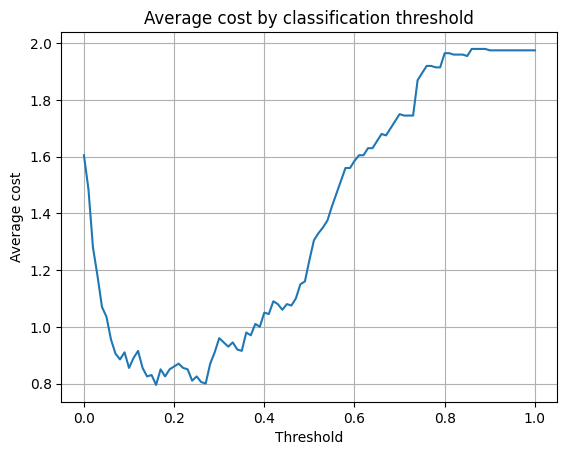

In [8]:
false_negative_cost = 10
false_positive_cost = 2

def classification_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)   #threshold decision

    false_negative = np.sum((y_true==1)&(y_pred==0))
    false_positive = np.sum((y_true==0)&(y_pred==1))

    total_cost = false_positive_cost * false_positive + false_negative_cost * false_negative
    avg_cost = total_cost / len(y_true)

    return avg_cost

thresholds = np.linspace(0, 1, 101)
costs = []

for t in thresholds:
    cost = classification_cost(y_test, y_proba, t)
    costs.append(cost)

costs = np.array(costs)

#index of minimum cost
best_idx = np.argmin(costs)
optimal_threshold = thresholds[best_idx]
optimal_cost = costs[best_idx]

print("Optimal threshold:", optimal_threshold)
print("Optimal cost:", optimal_cost)

plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Average cost")
plt.title("Average cost by classification threshold")
plt.grid()
plt.show()


## Problem 3 — Confusion Matrix Comparison

Tasks:
1. Calculate confusion matrix for threshold 0.5.
2. Calculate confusion matrix for optimal threshold.
3. Compare precision and recall.
4. Explain which threshold is better when false negatives are expensive.

Hints:
- `confusion_matrix(y_test, y_pred)` returns:
  - TN, FP
  - FN, TP
- Lower threshold usually increases recall.
- Higher threshold usually increases precision.


In [ ]:
def metrics_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int) 
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cost": classification_cost(y_true, y_proba, threshold),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

comparison = []
comparison.append(metrics_at_threshold(y_test, y_proba, 0.5))
comparison.append(metrics_at_threshold(y_test, y_proba, optimal_threshold))

pd.DataFrame(comparison)


Which threshold is better, when false negatives are expensive: When false negatives are expensive, a smaller classification threshold is preferable because it increases recall and reduces the number of missed positive cases. Although precision decreases, the overall expected cost becomes lower.

# Day 5 — Review Questions and Mini Exam

## Conceptual Questions

1. What is the difference between prediction label and prediction probability?
2. What does a classification threshold do?
3. What is a false positive?
4. What is a false negative?
5. When is recall more important than precision?
6. Why can threshold 0.5 be non-optimal?
7. What does logistic regression model?

## Mini Exam Task

Create a binary classification dataset. Fit logistic regression. Then:
- calculate predicted probabilities
- test thresholds from 0 to 1
- find best threshold by custom cost
- compare precision and recall at threshold 0.5 and best threshold



---

<a id="day6"></a>

# Day6

**Source file:** `Day6_Markov_Chains_WITH_HINTS.ipynb`



# Day 6 Mock Assignments — Markov Chains Intensive

Topics:
- transition matrix
- simulation of Markov chains
- state probabilities
- stationary distribution
- hitting time
- long-run behavior

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Problem 1 — Three-State Markov Chain

Consider states:
- 0 = Sunny
- 1 = Cloudy
- 2 = Rainy

Transition matrix:

$$
P =
\begin{pmatrix}
0.7 & 0.2 & 0.1 \\
0.3 & 0.4 & 0.3 \\
0.2 & 0.3 & 0.5
\end{pmatrix}
$$

Tasks:
1. Check that each row sums to 1.
2. Simulate one Markov chain of length 100.
3. Count how often each state appears.
4. Estimate empirical state frequencies.
5. Plot state over time.

Hints:
- Row `i` contains probabilities for next state given current state `i`.
- Use `rng.choice([0,1,2], p=P[current_state])`.
- Frequencies can be calculated with `np.bincount(chain, minlength=3) / len(chain)`.


[1. 1. 1.]
[53 28 19]
[0.53 0.28 0.19]


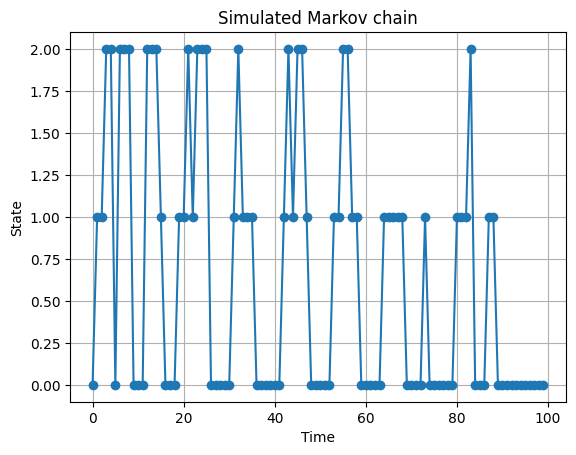

In [3]:
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
])

states = np.array([0, 1, 2])

# Part 1

row_sums = P.sum(axis=1)
print(row_sums)

'''
for i in states:
    row_sums = 0
    for j in states:
        row_sums = row_sums + P[i,j]
    if np.isclose(row_sums,1):
        print(row_sums)
    else:
        print ('Not == 1')
'''

# Part 2
T = 100
chain = np.zeros(T, dtype=int)
chain[0] = 0

for t in range(1, T):
    current_state = chain[t-1]
    chain[t] = rng.choice([0,1,2], p=P[current_state])
    #print(chain[t])


# Part 3 and 4
counts = np.bincount(chain, minlength=3)
frequencies = counts/len(chain)

print(counts)
print(frequencies)

# Part 5
plt.plot(chain, marker="o")
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Simulated Markov chain")
plt.grid()
plt.show()


## Problem 2 — Distribution After Many Steps

Start from state 0.

Tasks:
1. Define initial distribution `pi0 = [1, 0, 0]`.
2. Compute distribution after 1, 2, 5, 10, 50 steps.
3. Store results in a DataFrame.
4. Explain whether probabilities stabilize.

Hints:
- If `pi` is a row vector, next distribution is `pi @ P`.
- Repeated update: `pi = pi @ P`.
- Store each result as dictionary:
  - `step`
  - `Sunny`
  - `Cloudy`
  - `Rainy`


In [4]:
steps_to_save = [1, 2, 5, 10, 50]

pi = np.array([1.0, 0.0, 0.0])
results = []

for step in range(1, 51):
    pi = pi @ P

    if step in steps_to_save:
        results.append({
            "step": step,
            "Sunny": pi[0],
            "Cloudy": pi[1],
            "Rainy": pi[2]
        })

df_dist = pd.DataFrame(results)
df_dist


,step,Sunny,Cloudy,Rainy
0,1,0.700000,0.200000,0.100000
1,2,0.570000,0.250000,0.180000
2,5,0.468480,0.279400,0.252120
3,10,0.456805,0.282533,0.260662
4,50,0.456522,0.282609,0.260870


## Problem 3 — Stationary Distribution

A stationary distribution satisfies:

$$
\pi P = \pi
$$

Tasks:
1. Approximate stationary distribution by iterating many steps.
2. Verify that `pi @ P` is approximately equal to `pi`.
3. Compare with empirical frequencies from a long simulated chain.

Hints:
- Use 10,000 iterations.
- `np.allclose(pi @ P, pi)` checks approximate equality.
- Long-run simulation frequencies should be close to stationary distribution.


In [5]:
# Part 1
pi = np.array([1.0, 0.0, 0.0])

for i in range(10_000):
    pi = pi @ P

stationary = pi
print(stationary)

# Part 2
print(stationary @ P)
print(np.allclose(stationary @ P, stationary))

# Part 3
T = 50_000
chain = np.zeros(T, dtype=int)
chain[0] = 0

for t in range(1, T):
    current_state = chain[t-1]
    chain[t] = rng.choice([0,1,2], p=P[current_state])

empirical = np.bincount(chain, minlength=3)/len(chain)
print(empirical)



[0.45652174 0.2826087  0.26086957]
[0.45652174 0.2826087  0.26086957]
True
[0.4546  0.28254 0.26286]


## Problem 4 — Hitting Time

Hitting time means: how long until the chain first reaches a target state.

Target state: Rainy = 2.

Tasks:
1. Simulate `R = 5000` chains.
2. For each chain, start from Sunny = 0.
3. Record first time when state 2 is reached.
4. Estimate mean hitting time.
5. Plot histogram of hitting times.

Hints:
- Use a `while` loop.
- Stop when `current_state == target_state`.
- Add a safety maximum, for example `max_steps = 1000`.


6.692


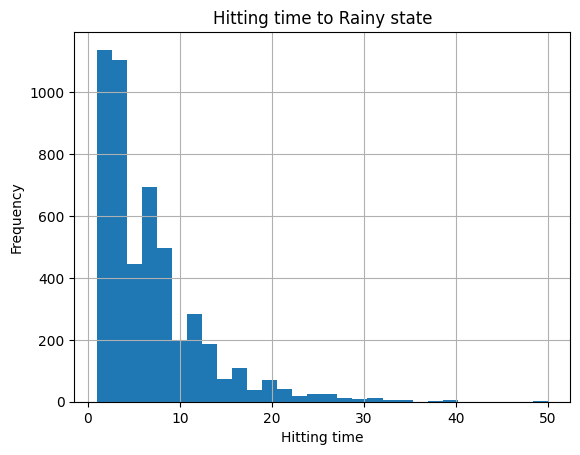

In [7]:
R = 5000
target_state = 2
max_steps = 1000


hitting_times = []

for r in range(R):
    current_state = 0
    t = 0

    while current_state != target_state and t < max_steps:
            current_state = rng.choice([0,1,2], p=P[current_state])
            t += 1

    hitting_times.append(t)


hitting_times = np.array(hitting_times)

mean_hitting_time = np.mean(hitting_times)
print(mean_hitting_time)

plt.hist(hitting_times, bins=30)
plt.xlabel("Hitting time")
plt.ylabel("Frequency")
plt.title("Hitting time to Rainy state")
plt.grid()
plt.show()


# Day 6 — Review Questions and Mini Exam

## Conceptual Questions

1. What is a transition matrix? A Transition matrix is a matrix where entry Pij gives the probabilities moving from state i to j in Markov chain
2. Why must each row sum to 1? Each row represents all possible next states from the current state. Since one of this outcomes must occur, the probability must sum to 1
3. What is a stationary distribution? A stationary distribution is probability distribution that remains unchanged after a transition. It satisfies pi * P = pi
4. What does long-run behavior mean? It describes the probabilities of being in each state after very large number of steps (transitions). These probabilities converge to the stationary distribution.
5. What is hitting time? Hitting time is number of steps need to reach target state in first time. 
6. Why can simulation and theoretical distribution be slightly different? Simulation uses a finite number of samples, so random variation (sampling error) occurs. As the number of simulations increases, the simulated distribution approaches the theoretical distribution

## Mini Exam Task

Create your own 2-state Markov chain. Then:
- check row sums
- simulate 10,000 steps
- estimate empirical state frequencies
- approximate stationary distribution
- compare both results



---

<a id="day7"></a>

# Day7

**Source file:** `Day7_Matrix_Algebra_SVD_Geometry_WITH_HINTS.ipynb`



# Day 7 Mock Assignments — Matrix Algebra, SVD & Geometry

Topics:
- vectors and norms
- dot products and cosine similarity
- high-dimensional geometry
- matrix rank
- SVD
- low-rank approximation

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Problem 1 — Near Orthogonality in High Dimensions

Generate random vectors in dimensions `d = 10, 100, 1000`.

Tasks:
1. Generate `R = 5000` pairs of random normal vectors for each dimension.
2. Normalize vectors.
3. Compute dot product for each pair.
4. Store mean and standard deviation of dot products.
5. Plot histogram for each dimension.
6. Explain what happens when dimension grows.

Hints:
- Dot product of normalized vectors is cosine similarity.
- Normalize by dividing by vector norm.
- `np.linalg.norm(x, axis=1)` gives row norms.
- For row-wise dot product use `np.sum(x * y, axis=1)`.


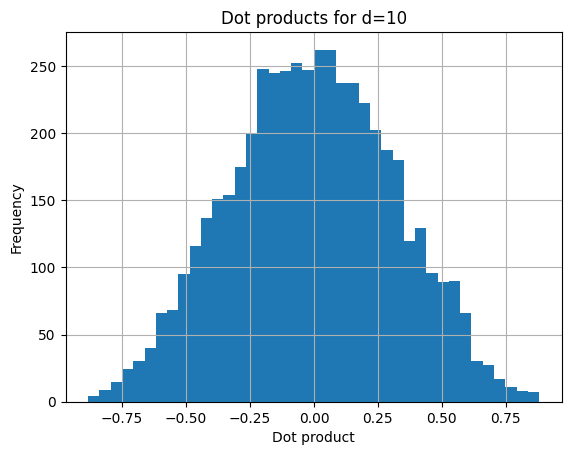

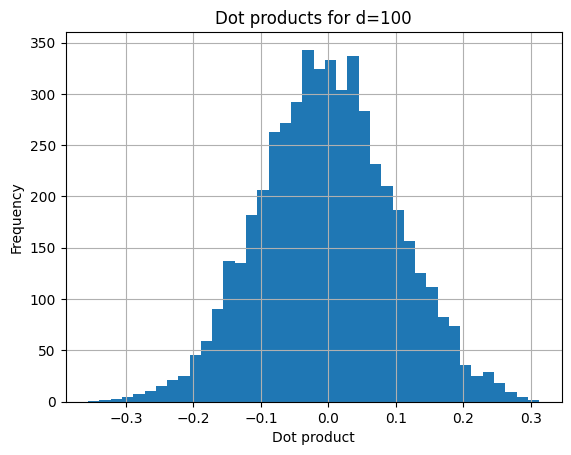

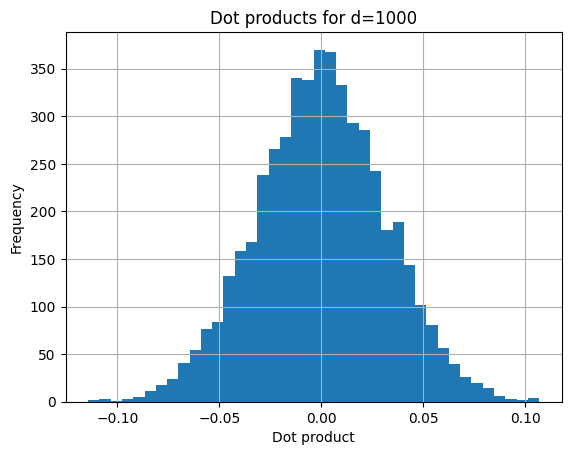

,d,mean_dot,std_dot
0,10,-0.005943,0.319665
1,100,-0.000547,0.100048
2,1000,-0.000028,0.031503


In [8]:
d_values = [10, 100, 1000]
R = 5000

results = []

for d in d_values:
    X = rng.normal(size=(R, d))
    Y = rng.normal(size=(R, d))

    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    #row-wise dot product
    dots = np.sum(X_norm * Y_norm, axis=1)

    results.append({
        "d": d,
        "mean_dot": np.mean(dots),
        "std_dot": np.std(dots)
    })

    plt.figure()
    plt.hist(dots, bins=40)
    plt.xlabel("Dot product")
    plt.ylabel("Frequency")
    plt.title(f"Dot products for d={d}")
    plt.grid()
    plt.show()

pd.DataFrame(results)


## Problem 2 — Rank-One Matrix

Create two vectors:

$$
u \in \mathbb{R}^{5}, \quad v \in \mathbb{R}^{4}
$$

and matrix:

$$
A = u v^T
$$

Tasks:
1. Create `u` and `v`.
2. Construct matrix `A`.
3. Print shape of `A`.
4. Compute matrix rank.
5. Explain why rank is 1.

Hints:
- Use `np.outer(u, v)`.
- Use `np.linalg.matrix_rank(A)`.
- A rank-one matrix is created from outer product of two vectors.


In [ ]:
u = np.array([1, 2, 3, 4, 5])
v = np.array([2, -1, 0, 3])

A = np.outer(u,v)   #same as A = np.outer(u,v.T)

print(A)
print(A.shape)

rank = np.linalg.matrix_rank(A)
print(rank)


[[ 2 -1  0  3]
 [ 4 -2  0  6]
 [ 6 -3  0  9]
 [ 8 -4  0 12]
 [10 -5  0 15]]
(5, 4)
1


ANSWER: The matrix A is constructed as the outer product A=uvT
.Every row is a scalar multiple of the first row, and every column is a scalar multiple of u. Therefore there is only one linearly independent row (and column), so the matrix has rank 1.

## Problem 3 — SVD and Low-Rank Approximation

Tasks:
1. Create a random matrix `A` with shape `(50, 30)`.
2. Compute SVD.
3. Reconstruct `A` from SVD.
4. Create rank-1, rank-5, rank-10 approximations.
5. Calculate reconstruction error for each approximation.
6. Plot error as function of rank.

Hints:
- Use `U, S, Vt = np.linalg.svd(A, full_matrices=False)`.
- Rank-k approximation:
  `A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]`
- Error:
  `np.linalg.norm(A - A_k, ord="fro")`


In [11]:
A = rng.normal(size=(50, 30))

U, S, Vt = np.linalg.svd(A,full_matrices=False)

# Check shapes
print(U.shape, S.shape, Vt.shape)

ranks = [1, 5, 10, 20, 30]
errors = []

for k in ranks:
    A_k = U[:, :k] @np.diag(S[:k]) @Vt[:k, :]
    error = np.linalg.norm(A -A_k, ord="fro")
    errors.append(error)

df_errors = pd.DataFrame({
    "rank": ranks,
    "error": errors
})

df_errors


(50, 30) (30,) (30, 30)


,rank,error
0,1,3.539422e+01
1,5,2.916288e+01
2,10,2.215611e+01
3,20,1.007032e+01
4,30,8.583754e-14


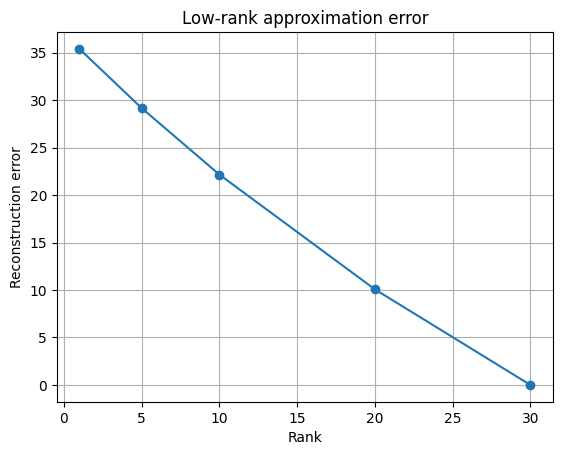

In [12]:
plt.plot(df_errors["rank"], df_errors["error"], marker="o")
plt.xlabel("Rank")
plt.ylabel("Reconstruction error")
plt.title("Low-rank approximation error")
plt.grid()
plt.show()


# Day 7 — Review Questions and Mini Exam

## Conceptual Questions

1. What is a vector norm? Vector norm is a mesure of the length or magnitude of a vector. For example, Eucledean norm.  
2. What does dot product measure? Dot product measures similarity between two vectors. For normalized vectors, the dot product equals to cosine of the angle between two vectors
3. Why are random high-dimensional vectors often nearly orthogonal? As dimension increases, the dot products of random normalized vectors tend to concentrate around 0. Therefore, random vectors become nearly perpendicular (orthogonal)
4. What is matrix rank? Matrix rank is the number of linerly independent rows or colums in the matrix
5. What does SVD decompose? SVD decompose matrix to left singular vectors U, singular values S and right singular vector Vt
6. Why does low-rank approximation reduce information? Low-rank approximation discards the smaller singular values and their corresponding singular vectors. Since these components contain part of the information in the original matrix, some information is lost

## Mini Exam Task

Generate a matrix with shape `(100, 20)`. Use SVD to:
- reconstruct the matrix
- create rank-1, rank-3 and rank-10 approximations
- calculate errors
- explain which rank is best and why


In [21]:
import numpy as np
#generate matrix
A = rng.normal(size=(100, 30))
#SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False) 
#print(A)
#print(U.shape, S.shape, Vt.shape)

#create rank-1, rank-3 and rank-10 approximations
ranks = [1,3,10]
errors = []

for k in ranks:
    A_k = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    error = np.linalg.norm(A - A_k)
    errors.append(error)
#calculate errors
#explain which rank is best and why

df_errors = pd.DataFrame({
    "rank": ranks,
    "error": errors
})

df_errors
#ANSWER: For rank-10 the approximation is the best due lowest error value =36.72. For rank 1 the approximation is the worst


,rank,error
0,1,52.285887
1,3,48.498476
2,10,36.276680



---

<a id="day8"></a>

# Day8

**Source file:** `Day8_Optimization_Count_Regression_WITH_HINTS.ipynb`



# Day 8 Mock Assignments — Optimization & Count Regression

Topics:
- Poisson regression
- negative log-likelihood
- gradient descent
- learning rate
- convergence
- count data

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Problem 1 — Derive and Implement Poisson Loss

For count data:

$$
Y_i \sim \mathrm{Poisson}(\lambda_i)
$$

with

$$
\lambda_i = \exp(\beta_0 + \beta_1 x_i)
$$

Tasks:
1. Generate synthetic count data.
2. Implement Poisson negative log-likelihood without constants.
3. Evaluate loss for several beta values.
4. Explain which beta gives lower loss.

Hints:
- Ignore `log(y!)` because it does not affect optimization.
- Negative log-likelihood can be written as:
  `np.mean(lambda_hat - y * eta)`
- where `eta = beta0 + beta1 * x`
- and `lambda_hat = np.exp(eta)`.


In [ ]:
n = 1000

x = rng.normal(size=n)

true_beta0 = 0.5
true_beta1 = 0.8

eta_true = true_beta0 + true_beta1 * x
lambda_true = np.exp(eta_true)

y = rng.poisson(lambda_true)

def poisson_loss(beta0, beta1, x, y):
    eta = beta0 + beta1 * x
    lambda_hat = np.exp(eta)
    loss = np.mean(lambda_hat - y * eta)
    return loss

test_results = []

for beta0 in [0.0, 0.5, 1.0]:
    for beta1 in [0.0, 0.8, 1.5]:
        test_results.append({
            "beta0": beta0,
            "beta1": beta1,
            "loss": poisson_loss(beta0, beta1, x, y)
        })

pd.DataFrame(test_results).sort_values("loss")

#ANSWER: beta0=0.5 and beta1=0.8 are giving less loss. Therefore the likelihood is maximized (equivalently the Poisson loss is minimized) near the true parameters.true_beta0 = 0.5, true_beta1 = 0.8


,beta0,beta1,loss
4,0.5,0.8,-0.318918
1,0.0,0.8,-0.086337
7,1.0,0.8,0.041056
6,1.0,0.0,0.426282
2,0.0,1.5,0.471344
3,0.5,0.0,0.502721
0,0.0,0.0,1.000000
5,0.5,1.5,1.448792
8,1.0,1.5,3.803766


## Problem 2 — Gradient Descent for Poisson Regression

Tasks:
1. Implement gradient descent for `beta0` and `beta1`.
2. Store loss at each iteration.
3. Plot loss curve.
4. Compare estimated beta values with true values.

Hints:
- `eta = beta0 + beta1 * x`
- `lambda_hat = np.exp(eta)`
- Gradient for beta0:
  `mean(lambda_hat - y)`
- Gradient for beta1:
  `mean((lambda_hat - y) * x)`
- Update:
  `beta = beta - learning_rate * gradient`


Estimated beta0: 0.4924085549318903
Estimated beta1: 0.7936741394119462


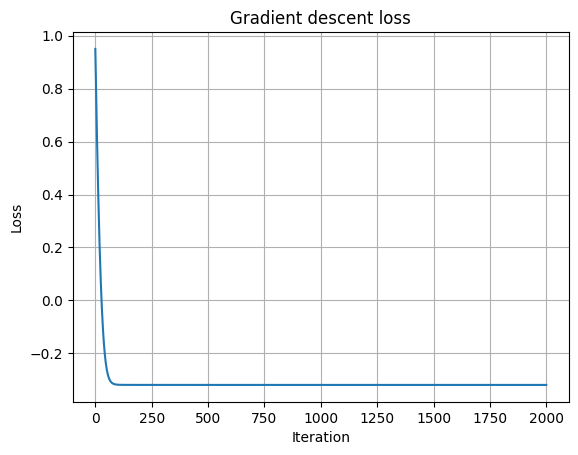

In [ ]:
beta0 = 0.0
beta1 = 0.0

learning_rate = 0.01
n_iter = 2000

losses = []

for i in range(n_iter):
    eta = beta0 + beta1 * x
    lambda_hat = np.exp(eta)

    grad_beta0 = np.mean(lambda_hat -y)
    grad_beta1 = np.mean((lambda_hat -y) * x)

    beta0 = beta0 - learning_rate * grad_beta0
    beta1 = beta1 - learning_rate * grad_beta1

    loss = poisson_loss(beta0, beta1, x, y)
    losses.append(loss)

print("Estimated beta0:", beta0)
print("Estimated beta1:", beta1)

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient descent loss")
plt.grid()
plt.show()

#COMMENT: The loss decreases quickly and then stabilizes, meaning gradient descent has converged. 
#The estimated parameters are close to the true parameters, so the model successfully recovered the underlying Poisson regression relationship.

## Problem 3 — Effect of Learning Rate

Tasks:
1. Try learning rates `0.001`, `0.01`, `0.1`.
2. Run gradient descent for each learning rate.
3. Store final loss and coefficients.
4. Explain what happens if learning rate is too small or too large.

Hints:
- Put gradient descent into a function.
- Too small learning rate: slow convergence.
- Too large learning rate: loss may explode or become `nan`.
- Use `np.isfinite(loss)` to check if loss is valid.


In [ ]:
def fit_poisson_gd(x, y, learning_rate=0.01, n_iter=1000):
    beta0 = 0.0
    beta1 = 0.0
    losses = []

    for i in range(n_iter):
        eta = beta0 + beta1 * x
        lambda_hat = np.exp(eta)

        grad_beta0 = np.mean(lambda_hat -y)
        grad_beta1 = np.mean((lambda_hat -y) * x)

        beta0 = beta0 - learning_rate * grad_beta0
        beta1 = beta1 - learning_rate * grad_beta1

        loss = poisson_loss(beta0, beta1, x, y)
        losses.append(loss)

        if not np.isfinite(loss):
            break

    return beta0, beta1, losses

learning_rates = [0.001, 0.01, 0.1]
results = []

for lr in learning_rates:
    b0, b1, losses_lr = fit_poisson_gd(x, y, learning_rate=lr, n_iter=1000)
    results.append({
        "learning_rate": lr,
        "beta0": b0,
        "beta1": b1,
        "final_loss": losses_lr[-1],
        "iterations_completed": len(losses_lr)
    })

pd.DataFrame(results)

#ANSWER: If learning rate is too small, then algorithm coverges very slowly. If learning rate is high, then learning can be unstable (oscillate) and also can overshoot global minimum. 


,learning_rate,beta0,beta1,final_loss,iterations_completed
0,0.001,0.502752,0.766896,-0.318185,1000
1,0.010,0.492410,0.793673,-0.319151,1000
2,0.100,0.492409,0.793674,-0.319151,1000


# Day 8 — Review Questions and Mini Exam

## Conceptual Questions

1. When is Poisson regression useful? Poisson regression is useful for modelling count data, such as the number of events occuring in the fixed time period or area.
2. Why do we use `exp(eta)` for the Poisson rate? We use exp(eta), because the Poisson rate lambda must always be positive. The exponential function garantees positive values for all eta.
3. What is negative log-likelihood? Negative log-likelihood is the loss function used in Poisson regression. Minimizing it is equivalent to maximizing the likelihood of the observed data.
4. What does gradient descent minimize? Gradient descent minimizes Poisson loss
5. What can happen if learning rate is too large? if learnining rate is too high, then learning can be unstable, overshoot, diverge, oscissliate and create nan
6. What can happen if learning rate is too small? if learning rate is too small, then learning can converge very slowly and may require many iterations to reach the optimum. 

## Mini Exam Task

Generate count data with two features. Fit Poisson regression using gradient descent. Report:
- estimated coefficients
- final loss
- loss plot
- short explanation of convergence



---

<a id="day10"></a>

# Day10

**Source file:** `Day10_Final_Consolidation_WITH_HINTS.ipynb`



# Day 10 — Final Consolidation Notebook With Hints

Purpose:
- collect reusable exam templates
- repeat key patterns
- practice small tasks quickly

## General hints

- Read the full task first.
- Keep variable names exactly as requested where possible.
- Test your code on small examples before using large simulations.
- Use `print(...)`, `df.head()`, and `.shape` often.
- Store results in a list of dictionaries, then convert to `pandas.DataFrame`.
- For plots, always add labels, title, grid, and legend if comparing multiple lines.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score

## Template 1 — Simulation Study

Use this template when task says:
- simulate many experiments
- estimate bias
- estimate variance
- estimate MSE
- estimate coverage

Tasks:
1. Simulate `R` repetitions.
2. Calculate estimator for each repetition.
3. Calculate mean estimator, bias, standard error and MSE.
4. Store result in dictionary.

Hints:
- Usually `data.shape == (R, n)`.
- Use `axis=1` to calculate one estimator per row.
- Bias: `np.mean(estimates) - true_value`
- MSE: `np.mean((estimates - true_value)**2)`


In [ ]:
true_value = 0.4
n = 100
R = 5000

data = rng.binomial(1, true_value, size=(R, n))

estimates = ...

bias = ...
se = ...
mse = ...

{
    "bias": bias,
    "se": se,
    "mse": mse
}


## Template 2 — Confidence Interval Coverage

Tasks:
1. Write interval function.
2. Simulate data.
3. Check if interval contains true value.
4. Estimate coverage and average length.

Hints:
- Coverage is mean of Boolean values.
- `True` counts as 1 and `False` counts as 0 in NumPy.


In [ ]:
def hoeffding_interval(data, alpha=0.05):
    n = ...
    means = ...
    radius = ...
    lower = ...
    upper = ...
    return lower, upper

p = 0.4
alpha = 0.05
R = 5000
n = 100

data = rng.binomial(1, p, size=(R, n))
lower, upper = hoeffding_interval(data, alpha)

coverage = ...
avg_length = ...

coverage, avg_length


## Template 3 — Linear Regression

Tasks:
1. Prepare `X` and `y`.
2. Split train/test.
3. Fit model.
4. Predict.
5. Calculate RMSE and $R^2$.

Hints:
- `X` must be 2D.
- `y` can be 1D.
- Use DataFrame column list for multiple features.


In [ ]:
n = 500
x = rng.normal(size=n)
noise = rng.normal(0, 1, size=n)
y = 2 + 3*x + noise

df = pd.DataFrame({"x": x, "y": y})

X = ...
y = ...

X_train, X_test, y_train, y_test = ...

model = LinearRegression()
...

y_pred = ...

rmse = ...
r2 = ...

rmse, r2


## Template 4 — Logistic Regression and Threshold

Tasks:
1. Fit logistic regression.
2. Predict probabilities.
3. Convert probabilities to labels using threshold.
4. Calculate precision, recall and F1.

Hints:
- Use `predict_proba(X_test)[:, 1]`.
- Label prediction:
  `(y_proba >= threshold).astype(int)`


In [ ]:
n = 1000
x = rng.normal(size=n)
prob = 1 / (1 + np.exp(-(0.5 + 2*x)))
y = rng.binomial(1, prob)

df = pd.DataFrame({"x": x, "y": y})

X = ...
y = ...

X_train, X_test, y_train, y_test = ...

model = LogisticRegression()
...

y_proba = ...

threshold = 0.5
y_pred = ...

{
    "accuracy": ...,
    "precision": ...,
    "recall": ...,
    "f1": ...
}


## Template 5 — Markov Chain

Tasks:
1. Check transition matrix.
2. Simulate chain.
3. Estimate state frequencies.
4. Approximate stationary distribution.

Hints:
- `P[current_state]` is the probability vector for next state.
- `pi = pi @ P` updates theoretical distribution.


In [ ]:
P = np.array([
    [0.9, 0.1],
    [0.3, 0.7]
])

print(P.sum(axis=1))

T = 10000
chain = np.zeros(T, dtype=int)

for t in range(1, T):
    current_state = ...
    chain[t] = ...

empirical = ...
print(empirical)

pi = np.array([1.0, 0.0])
for i in range(10000):
    pi = ...

print(pi)


## Template 6 — SVD

Tasks:
1. Compute SVD.
2. Create low-rank approximation.
3. Calculate reconstruction error.

Hints:
- Always use `full_matrices=False` for easier shapes.
- Frobenius norm: `np.linalg.norm(A - A_k, ord="fro")`


In [ ]:
A = rng.normal(size=(60, 30))

U, S, Vt = ...

k = 5
A_k = ...

error = ...
error


# Day 10 — Final Self-Test

Try to answer without looking up:

1. How do you calculate row means in NumPy?
2. How do you simulate Bernoulli data?
3. How do you calculate bias?
4. How do you calculate MSE?
5. How do you calculate a Hoeffding radius?
6. How do you get logistic regression probabilities?
7. What is false negative?
8. What does Markov transition matrix row mean?
9. What does SVD do?
10. How do you create a rank-k approximation?

## Final exam strategy

- Start with easy parts.
- Print shapes often.
- Use simple variable names.
- Do not overcomplicate.
- If stuck, write pseudocode first.
- Always create a small test example.
